# Research Questions: Prediksi Kandungan Organik Tanah


## Setup


In [11]:
import os
import gc
import time
import warnings
from itertools import combinations
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".mplconfig").resolve())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from scipy import stats
from scipy.optimize import minimize
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42
TARGET = "property_organic_content"
N_FOLDS = 5
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
GREEN = "#2D6A4F"
LIGHT_GREEN = "#74C69D"
DARK_GREEN = "#1B4332"
ORANGE = "#F4A261"
RED = "#C1121F"
BLUE = "#457B9D"
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
y = train[TARGET].copy()
y_values = y.to_numpy()
groups = train["source_id"].to_numpy()

assert TARGET in train.columns
assert train["sample_id"].is_unique
assert test["sample_id"].is_unique
print(f"Train shape: {train.shape}")
print(f"Target mean: {y.mean():.4f} | median: {y.median():.4f} | skewness: {y.skew():.4f}")


Train shape: (11210, 52)
Target mean: 34.1425 | median: 27.5065 | skewness: 2.0278


In [12]:
def regression_metrics(y_true, y_pred):
    y_pred_nonnegative = np.clip(np.asarray(y_pred), 0, None)
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred_nonnegative)),
        "R2": r2_score(y_true, y_pred),
    }


def bootstrap_mean_ci(values, n_boot=500, confidence=0.95, seed=RANDOM_STATE):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return values[0], values[0]
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = 1 - confidence
    return (
        np.quantile(boot_means, alpha / 2),
        np.quantile(boot_means, 1 - alpha / 2),
    )


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        (len(p_values) - np.arange(len(p_values))) * p_values[order]
    )
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.clip(adjusted_sorted, 0, 1)
    return adjusted


def eta_squared(data, group_col, target_col=TARGET):
    grand_mean = data[target_col].mean()
    ss_between = sum(
        len(group) * (group[target_col].mean() - grand_mean) ** 2
        for _, group in data.groupby(group_col)
    )
    ss_total = ((data[target_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total


def make_indep(df_all):
    X = df_all.drop(columns=[TARGET], errors="ignore").copy()
    X = X.drop(columns=["sample_id"], errors="ignore")
    band_a = [c for c in X.columns if c.startswith("spectral_band_A_PC_")]
    band_b = [c for c in X.columns if c.startswith("spectral_band_B_PC_")]
    eps = 1e-6

    X["missing_total"] = X.isna().sum(axis=1)
    X["band_B_available_actual_num"] = X[band_b].notna().any(axis=1).astype(int)
    X["band_B_missing_count"] = X[band_b].isna().sum(axis=1)
    X["coord_available_num"] = X[["latitude", "longitude"]].notna().all(axis=1).astype(int)
    X["chem_missing_count"] = X[[
        "property_acidity_index", "cation_Ca", "cation_Mg",
        "cation_Na", "cation_exchange_capacity",
    ]].isna().sum(axis=1)

    for p, cols in [("A", band_a), ("B", band_b)]:
        V = X[cols]
        X[f"{p}_mean"] = V.mean(axis=1)
        X[f"{p}_std"] = V.std(axis=1)
        X[f"{p}_min"] = V.min(axis=1)
        X[f"{p}_max"] = V.max(axis=1)
        X[f"{p}_l2"] = np.sqrt((V ** 2).sum(axis=1))
        X[f"{p}_abs_sum"] = V.abs().sum(axis=1)
        X[f"{p}_max_abs"] = V.abs().max(axis=1)
        for c in cols[:3]:
            X[c + "_abs"] = X[c].abs()
            X[c + "_sq"] = X[c] ** 2

    X["particle_total"] = X["property_particle_coarse"] + X["property_particle_fine"]
    X["fine_fraction"] = X["property_particle_fine"] / (X["particle_total"] + eps)
    X["fine_to_coarse"] = X["property_particle_fine"] / (X["property_particle_coarse"] + eps)
    X["fine_minus_coarse"] = X["property_particle_fine"] - X["property_particle_coarse"]

    X["base_cation_sum"] = X[["cation_Ca", "cation_Mg", "cation_Na"]].sum(axis=1)
    X["ca_mg_ratio"] = X["cation_Ca"] / (X["cation_Mg"] + eps)
    X["mg_ca_ratio"] = X["cation_Mg"] / (X["cation_Ca"] + eps)
    X["base_saturation_proxy"] = X["base_cation_sum"] / (X["cation_exchange_capacity"] + eps)
    X["ca_cec_ratio"] = X["cation_Ca"] / (X["cation_exchange_capacity"] + eps)
    X["mg_cec_ratio"] = X["cation_Mg"] / (X["cation_exchange_capacity"] + eps)
    X["cec_per_fine"] = X["cation_exchange_capacity"] / (X["property_particle_fine"] + eps)
    X["acidity_x_cec"] = X["property_acidity_index"] * X["cation_exchange_capacity"]
    X["acidity_per_cec"] = X["property_acidity_index"] / (X["cation_exchange_capacity"] + eps)
    for c in ["cation_exchange_capacity", "cation_Ca", "cation_Mg", "property_acidity_index"]:
        X["log1p_" + c] = np.log1p(X[c])

    X["abs_latitude"] = X["latitude"].abs()
    X["abs_longitude"] = X["longitude"].abs()
    X["lat_lon_sum"] = X["latitude"] + X["longitude"]
    X["lat_lon_diff"] = X["latitude"] - X["longitude"]
    X["lat_lon_prod"] = X["latitude"] * X["longitude"]
    X["lat_round_1"] = X["latitude"].round(1)
    X["lon_round_1"] = X["longitude"].round(1)

    def inter(cols, name):
        X[name] = X[cols].astype("string").fillna("NA").agg("|".join, axis=1)

    for cols, name in [
        (["geo_zone_macro", "geo_zone_meso", "geo_zone_micro"], "geo_hierarchy"),
        (["biome", "land_cover_type"], "biome_landcover"),
        (["source_id", "geo_zone_micro"], "source_micro"),
        (["source_id", "land_cover_type"], "source_landcover"),
        (["geo_zone_meso", "land_cover_type"], "meso_landcover"),
        (["land_cover_type", "parent_rock_type"], "landcover_rock"),
        (["source_id", "parent_rock_type"], "source_rock"),
    ]:
        inter(cols, name)
    X["latlon_grid1"] = (
        X["lat_round_1"].astype("string").fillna("NA")
        + "|"
        + X["lon_round_1"].astype("string").fillna("NA")
    )

    X["_source_id_raw"] = X["source_id"].astype("string")
    X["_geo_zone_macro_raw"] = X["geo_zone_macro"].astype("string")
    X["_biome_raw"] = X["biome"].astype("string")
    X["_parent_rock_type_raw"] = X["parent_rock_type"].astype("string")

    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    cat_cols = [c for c in cat_cols if not c.startswith("_")]
    X_enc = X.copy()
    for c in cat_cols:
        s = X[c].astype("string").fillna("NA")
        freq = s.value_counts(dropna=False)
        X_enc[c + "_freq"] = s.map(freq).astype(float)
        vals = {v: i for i, v in enumerate(s.unique())}
        X_enc[c] = s.map(vals).astype("int32")

    nun = X_enc.nunique(dropna=False)
    drop_const = [c for c in nun[nun <= 1].index.tolist() if not c.startswith("_")]
    X_enc = X_enc.drop(columns=drop_const)
    X_enc = X_enc.replace([np.inf, -np.inf], np.nan)
    return X_enc, cat_cols


all_df = pd.concat([train, test], ignore_index=True, sort=False)
X_all, cat_str_cols = make_indep(all_df)
X = X_all.iloc[:len(train)].reset_index(drop=True)
X_test = X_all.iloc[len(train):].reset_index(drop=True)
RAW_COLS = [c for c in X.columns if c.startswith("_")]

te_source_cols_full = [
    "source_id", "geo_zone_macro", "geo_zone_meso", "geo_zone_micro",
    "land_cover_type", "biome", "parent_rock_type", "sampling_strategy",
    "geo_hierarchy", "biome_landcover", "source_micro", "source_landcover",
    "meso_landcover", "landcover_rock", "source_rock", "latlon_grid1",
]
HIGH_RISK_TE_COLS = {"source_micro", "source_landcover", "source_rock", "latlon_grid1"}
te_source_cols = [
    c for c in te_source_cols_full
    if c in X.columns and c not in HIGH_RISK_TE_COLS
]
te_source_cols_standard = [c for c in te_source_cols if c != "source_id"]


def simple_te_series(cat_tr, y_tr, cat_apply, m, gmean):
    stats_df = pd.DataFrame({"cat": cat_tr, "y": y_tr}).groupby("cat")["y"].agg(["count", "mean"])
    enc = (stats_df["mean"] * stats_df["count"] + gmean * m) / (stats_df["count"] + m)
    return pd.Series(cat_apply).map(enc).fillna(gmean).values, stats_df


def add_te_fold(X_tr_base, y_tr, X_va_base, X_te_base, cols, ms=(50, 200)):
    X_tr = X_tr_base.copy()
    X_va = X_va_base.copy()
    X_te = X_te_base.copy()
    gmean = float(np.mean(y_tr))
    for c in cols:
        cat = X_tr_base[c].values
        for m in ms:
            enc_tr, _ = simple_te_series(cat, y_tr, cat, m, gmean)
            X_tr[f"{c}_te_m{m}"] = enc_tr
            X_va[f"{c}_te_m{m}"], _ = simple_te_series(cat, y_tr, X_va_base[c].values, m, gmean)
            X_te[f"{c}_te_m{m}"], _ = simple_te_series(cat, y_tr, X_te_base[c].values, m, gmean)
        cnt = pd.DataFrame({"cat": cat, "y": y_tr}).groupby("cat")["y"].agg("count")
        X_tr[f"{c}_te_count"] = pd.Series(cat).map(cnt).fillna(0).values
        X_va[f"{c}_te_count"] = pd.Series(X_va_base[c].values).map(cnt).fillna(0).values
        X_te[f"{c}_te_count"] = pd.Series(X_te_base[c].values).map(cnt).fillna(0).values
    return X_tr, X_va, X_te


def add_anchored_te_source(X_tr, X_va, X_te, X_tr_raw, X_va_raw, X_te_raw, y_tr, ms=(50, 200)):
    gmean = float(np.mean(y_tr))
    anchor_cols_raw = ["_geo_zone_macro_raw", "_biome_raw", "_parent_rock_type_raw"]

    def region_prior_for(df_raw):
        parts = []
        for c in anchor_cols_raw:
            enc, _ = simple_te_series(X_tr_raw[c].values, y_tr, df_raw[c].values, 100, gmean)
            parts.append(enc)
        return np.mean(parts, axis=0)

    region_prior_tr = region_prior_for(X_tr_raw)
    region_prior_va = region_prior_for(X_va_raw)
    region_prior_te = region_prior_for(X_te_raw)

    src_tr = X_tr_raw["_source_id_raw"].values
    stats_df = pd.DataFrame({
        "cat": src_tr,
        "y": y_tr,
        "prior": region_prior_tr,
    }).groupby("cat").agg(
        count=("y", "count"),
        mean=("y", "mean"),
        prior=("prior", "mean"),
    )

    for m in ms:
        enc_map = (
            stats_df["mean"] * stats_df["count"] + stats_df["prior"] * m
        ) / (stats_df["count"] + m)
        X_tr[f"source_id_anchte_m{m}"] = pd.Series(src_tr).map(enc_map).fillna(gmean).values
        X_va[f"source_id_anchte_m{m}"] = pd.Series(X_va_raw["_source_id_raw"].values).map(enc_map).fillna(gmean).values
        X_te[f"source_id_anchte_m{m}"] = pd.Series(X_te_raw["_source_id_raw"].values).map(enc_map).fillna(gmean).values
    cnt = stats_df["count"]
    X_tr["source_id_te_count"] = pd.Series(src_tr).map(cnt).fillna(0).values
    X_va["source_id_te_count"] = pd.Series(X_va_raw["_source_id_raw"].values).map(cnt).fillna(0).values
    X_te["source_id_te_count"] = pd.Series(X_te_raw["_source_id_raw"].values).map(cnt).fillna(0).values
    X_tr["region_prior"] = region_prior_tr
    X_va["region_prior"] = region_prior_va
    X_te["region_prior"] = region_prior_te
    return X_tr, X_va, X_te


def add_te_full(X_tr0, y_tr, X_va0, X_te0):
    X_tr, X_va, X_te = add_te_fold(X_tr0, y_tr, X_va0, X_te0, te_source_cols_standard)
    X_tr, X_va, X_te = add_anchored_te_source(
        X_tr, X_va, X_te, X_tr0, X_va0, X_te0, y_tr
    )
    return X_tr, X_va, X_te


def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))


def print_table(title, data, max_rows=None):
    print(title)
    if isinstance(data, pd.Series):
        print(data.to_string())
    else:
        if max_rows is not None:
            print(data.head(max_rows).to_string())
        else:
            print(data.to_string())
    print()


print(f"Final feature matrix shape: train={X.shape}, test={X_test.shape}")
print(f"Raw categorical columns encoded by make_indep: {len(cat_str_cols)}")
print(f"Raw shadow columns kept only for target encoding: {len(RAW_COLS)}")
print(f"Fold-safe standard target-encoding columns: {len(te_source_cols_standard)}")


Final feature matrix shape: train=(11210, 132), test=(2670, 132)
Raw categorical columns encoded by make_indep: 19
Raw shadow columns kept only for target encoding: 4
Fold-safe standard target-encoding columns: 11


## Ringkasan data


Ringkasan jumlah data, fitur, sumber, wilayah, missing Band B, dan statistik target.
                         nilai
jumlah_sampel      11,210.0000
jumlah_fitur           51.0000
jumlah_source          35.0000
jumlah_zona_macro       5.0000
jumlah_zona_meso       23.0000
jumlah_zona_micro      50.0000
band_B_missing_pct     84.8885
target_mean            34.1425
target_median          27.5065
target_skewness         2.0278


Statistik target:
Mean     : 34.143
Median   : 27.507
Std      : 23.199
Min/Max  : 2.16 / 195.23
Skewness : 2.028 -> right-skewed, log-transform direkomendasikan
Outlier  : 495 sampel (4.4%) di atas 82.03


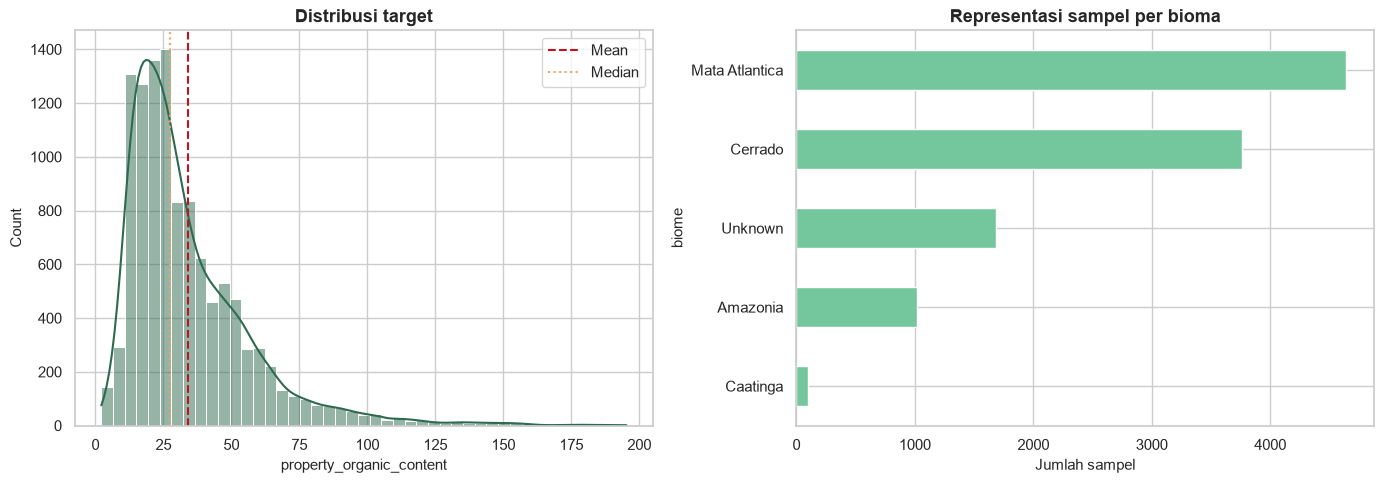

In [13]:
band_b_cols = [c for c in train.columns if c.startswith("spectral_band_B_PC_")]
overview = pd.Series({
    "jumlah_sampel": len(train),
    "jumlah_fitur": train.shape[1] - 1,
    "jumlah_source": train["source_id"].nunique(),
    "jumlah_zona_macro": train["geo_zone_macro"].nunique(),
    "jumlah_zona_meso": train["geo_zone_meso"].nunique(),
    "jumlah_zona_micro": train["geo_zone_micro"].nunique(),
    "band_B_missing_pct": train[band_b_cols].isna().all(axis=1).mean() * 100,
    "target_mean": y.mean(),
    "target_median": y.median(),
    "target_skewness": y.skew(),
})
print_table("Ringkasan jumlah data, fitur, sumber, wilayah, missing Band B, dan statistik target.", overview.to_frame("nilai"))

q1, q3 = y.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_upper = q3 + 1.5 * iqr
outlier_mask = y > outlier_upper
skewness = y.skew()
if skewness > 1:
    skew_note = "right-skewed, log-transform direkomendasikan"
elif skewness < -1:
    skew_note = "left-skewed"
else:
    skew_note = "relatif simetris"

print("\nStatistik target:")
print(f"Mean     : {y.mean():.3f}")
print(f"Median   : {y.median():.3f}")
print(f"Std      : {y.std():.3f}")
print(f"Min/Max  : {y.min():.2f} / {y.max():.2f}")
print(f"Skewness : {skewness:.3f} -> {skew_note}")
print(f"Outlier  : {outlier_mask.sum():,} sampel ({outlier_mask.mean() * 100:.1f}%) di atas {outlier_upper:.2f}")

_, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=45, kde=True, color=GREEN, ax=axes[0])
axes[0].axvline(y.mean(), color=RED, ls="--", label="Mean")
axes[0].axvline(y.median(), color=ORANGE, ls=":", label="Median")
axes[0].set_title("Distribusi target")
axes[0].legend()

train["biome"].value_counts().sort_values().plot(
    kind="barh", color=LIGHT_GREEN, ax=axes[1]
)
axes[1].set_title("Representasi sampel per bioma")
axes[1].set_xlabel("Jumlah sampel")
plt.tight_layout()
plt.show()


Visualisasi menunjukkan bahwa nilai property_organic_content mayoritas berada pada rentang rendah hingga sedang, sekitar 10–50. Rata-rata target sebesar 34.143 dan median 27.507, dengan rentang nilai 2.16–195.23 serta standar deviasi 23.199.

Distribusi data miring ke kanan / right-skewed dengan skewness 2.028, karena terdapat beberapa nilai sangat tinggi. Terdapat 495 outlier atau sekitar 4.4% data dengan nilai di atas 82.03, sehingga log-transform direkomendasikan.

Dari sisi bioma, sampel paling banyak berasal dari Mata Atlantica dan Cerrado, sedangkan Caatinga memiliki sampel paling sedikit. Ini menunjukkan data masih belum seimbang antarbioma.

# Soal 1: Urgensi bisnis dan kebijakan pangan

> **Dalam konteks bisnis pertanian dan kebijakan pangan, apakah memprediksi kandungan organik tanah
> merupakan hal yang mendesak? Jelaskan urgensinya dari perspektif efisiensi biaya operasional dan
> manajemen lahan berkelanjutan!**

## Pendekatan dan asumsi

Jawaban menggabungkan konteks dataset dengan literatur FAO dan IPCC. Karena dataset tidak menyediakan
data biaya, notebook tidak mengarang nominal penghematan. Efisiensi dijelaskan melalui perubahan alur
kerja dan alokasi sumber daya.

## Jawaban Soal 1

**Ya, prediksi kandungan organik tanah mendesak sebagai alat screening dan prioritisasi.**

1. **Efisiensi biaya operasional.** Pengujian laboratorium merata membutuhkan pengambilan sampel,
   transportasi, preparasi, reagen, instrumen, dan waktu analis. Model dapat membuat peta risiko awal,
   sehingga laboratorium difokuskan pada lokasi bernilai ekstrem, berketidakpastian tinggi, atau penting
   secara kebijakan. Penghematan berasal dari *targeted sampling*, bukan dari menghapus laboratorium.
2. **Efisiensi input pertanian.** Kandungan organik berkaitan dengan kesuburan, retensi air, struktur
   tanah, dan jasa ekosistem. Informasi spasial yang lebih cepat mendukung pemberian bahan organik,
   pemupukan, dan konservasi yang spesifik lokasi.
3. **Manajemen berkelanjutan.** Prediksi berulang membantu mendeteksi degradasi dan memprioritaskan
   rehabilitasi. FAO menyatakan bahwa soil organic carbon penting bagi kesehatan, kesuburan, produksi
   pangan, dan jasa ekosistem; IPCC juga menempatkan pengelolaan lahan berkelanjutan sebagai bagian dari
   ketahanan pangan dan mitigasi/adaptasi iklim.
4. **Batas keputusan.** Model tidak mengukur stok karbon secara langsung dan tidak membuktikan sebab
   perubahan. Keputusan berisiko tinggi tetap memerlukan konfirmasi laboratorium, audit error per
   wilayah, dan pembaruan model.

**Kesimpulan:** urgensinya tinggi ketika model dipakai untuk mempercepat dan memprioritaskan tindakan,
bukan ketika diposisikan sebagai pengganti absolut metode referensi.

Referensi: [FAO — Soil Organic Carbon](https://www.fao.org/global-soil-partnership/areas-of-work/soil-organic-carbon/en/);
[IPCC — Climate Change and Land](https://www.ipcc.ch/srccl/).

**Keterbatasan:** dataset tidak memiliki komponen biaya dan tanggal pemantauan, sehingga besaran ROI
serta kemampuan mendeteksi tren waktu belum dapat dihitung.

# Soal 2: Overfit atau underfit

> **Apakah model prediksi kandungan organik tanah Anda mengalami overfit atau underfit? Tunjukkan
> buktinya secara empiris melalui metrik evaluasi atau melalui visualisasi yang relevan, serta jelaskan
> langkah mitigasi yang Anda lakukan! Jika tidak mengalami keduanya, jelaskan alasannya!**

## Pendekatan dan asumsi

Bagian ini menjalankan ulang pipeline model final langsung dari `data/train.csv` dan `data/test.csv`. Bukti overfit/underfit berasal dari OOF prediction base model, evaluasi nested `source_id` GroupKFold untuk ensemble, baseline median, dan audit error per kelompok.


In [14]:
FINAL_MODEL_NAME = "Final stacked ensemble + conservative high-tail correction"
TAIL_THRESHOLD = 85.0
TAIL_ALPHA = 0.316
STACK_RIDGE_ALPHA = 5.0
Y_MAX = float(np.percentile(y_values, 99.5))
model_start_time = time.time()

results = []
oofs = {}
preds = {}
fold_details = []


def add_result(score, oof, pred):
    results.append(score)
    oofs[score["name"]] = oof
    preds[score["name"]] = pred
    for row in score["rows"]:
        fold_details.append({"model": score["name"], **row})


def run_cat(name, params, seeds=(91, 202), n_splits=5, log_target=False):
    bins = pd.qcut(y, 10, labels=False, duplicates="drop")
    oof_accum = np.zeros(len(y_values))
    pred_accum = np.zeros(len(test))
    rows = []
    y_use_full = np.log1p(y_values) if log_target else y_values
    for seed in seeds:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.zeros(len(y_values))
        pred = np.zeros(len(test))
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, bins), 1):
            X_tr0 = X.iloc[tr_idx].reset_index(drop=True)
            X_va0 = X.iloc[va_idx].reset_index(drop=True)
            X_te0 = X_test.copy()
            y_tr = y_use_full[tr_idx]
            y_va_eval = y_values[va_idx]

            X_tr, X_va, X_te = add_te_full(X_tr0, y_tr, X_va0, X_te0)
            X_tr = X_tr.drop(columns=RAW_COLS)
            X_va = X_va.drop(columns=RAW_COLS)
            X_te = X_te.drop(columns=RAW_COLS)

            model = CatBoostRegressor(
                **params,
                random_seed=seed + fold,
                allow_writing_files=False,
                verbose=False,
                thread_count=4,
            )
            model.fit(
                X_tr,
                y_tr,
                eval_set=(X_va, y_use_full[va_idx]),
                early_stopping_rounds=200,
                verbose=False,
            )

            pv_raw = model.predict(X_va)
            pt_raw = model.predict(X_te)
            if log_target:
                pv = np.clip(np.expm1(pv_raw), 0, None)
                pt = np.clip(np.expm1(pt_raw), 0, None)
            else:
                pv = np.clip(pv_raw, 0, None)
                pt = np.clip(pt_raw, 0, None)
            oof[va_idx] = pv
            pred += pt / n_splits
            rows.append({
                "fold": fold,
                "seed": seed,
                "rmse": rmse(y_va_eval, pv),
                "best_iter": model.get_best_iteration(),
            })
            del model
            gc.collect()
        oof_accum += oof / len(seeds)
        pred_accum += pred / len(seeds)
    score = {
        "name": name,
        "rmse": rmse(y_values, oof_accum),
        "mae": mean_absolute_error(y_values, oof_accum),
        "r2": r2_score(y_values, oof_accum),
        "rows": rows,
    }
    print(f"Finished {name}: RMSE={score['rmse']:.5f}, MAE={score['mae']:.5f}, R2={score['r2']:.5f}")
    return score, oof_accum, pred_accum


def run_ridge_model(name, alpha=40.0, n_splits=5, seed=303):
    bins = pd.qcut(y, 10, labels=False, duplicates="drop")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(y_values))
    pred = np.zeros(len(test))
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, bins), 1):
        X_tr0 = X.iloc[tr_idx].reset_index(drop=True)
        X_va0 = X.iloc[va_idx].reset_index(drop=True)
        X_te0 = X_test.copy()
        y_tr = y_values[tr_idx]
        y_va_eval = y_values[va_idx]

        X_tr, X_va, X_te = add_te_full(X_tr0, y_tr, X_va0, X_te0)
        X_tr = X_tr.drop(columns=RAW_COLS)
        X_va = X_va.drop(columns=RAW_COLS)
        X_te = X_te.drop(columns=RAW_COLS)

        med = X_tr.median(numeric_only=True)
        X_tr_f = X_tr.fillna(med)
        X_va_f = X_va.fillna(med)
        X_te_f = X_te.fillna(med)

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_f)
        X_va_s = scaler.transform(X_va_f)
        X_te_s = scaler.transform(X_te_f)

        model = Ridge(alpha=alpha, random_state=seed)
        model.fit(X_tr_s, y_tr)
        pv = np.clip(model.predict(X_va_s), 0, None)
        pt = np.clip(model.predict(X_te_s), 0, None)
        oof[va_idx] = pv
        pred += pt / n_splits
        rows.append({"fold": fold, "rmse": rmse(y_va_eval, pv)})
    score = {
        "name": name,
        "rmse": rmse(y_values, oof),
        "mae": mean_absolute_error(y_values, oof),
        "r2": r2_score(y_values, oof),
        "rows": rows,
    }
    print(f"Finished {name}: RMSE={score['rmse']:.5f}, MAE={score['mae']:.5f}, R2={score['r2']:.5f}")
    return score, oof, pred


def run_lgb(name, params, seeds=(91,), n_splits=5, log_target=False):
    bins = pd.qcut(y, 10, labels=False, duplicates="drop")
    oof_accum = np.zeros(len(y_values))
    pred_accum = np.zeros(len(test))
    rows = []
    y_use_full = np.log1p(y_values) if log_target else y_values
    for seed in seeds:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.zeros(len(y_values))
        pred = np.zeros(len(test))
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, bins), 1):
            X_tr0 = X.iloc[tr_idx].reset_index(drop=True)
            X_va0 = X.iloc[va_idx].reset_index(drop=True)
            X_te0 = X_test.copy()
            y_tr = y_use_full[tr_idx]
            y_va_eval = y_values[va_idx]

            X_tr, X_va, X_te = add_te_full(X_tr0, y_tr, X_va0, X_te0)
            X_tr = X_tr.drop(columns=RAW_COLS)
            X_va = X_va.drop(columns=RAW_COLS)
            X_te = X_te.drop(columns=RAW_COLS)

            model = lgb.LGBMRegressor(
                **params,
                random_state=seed + fold,
                n_jobs=4,
                verbosity=-1,
            )
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_va, y_use_full[va_idx])],
                callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)],
            )

            pv_raw = model.predict(X_va)
            pt_raw = model.predict(X_te)
            if log_target:
                pv = np.clip(np.expm1(pv_raw), 0, None)
                pt = np.clip(np.expm1(pt_raw), 0, None)
            else:
                pv = np.clip(pv_raw, 0, None)
                pt = np.clip(pt_raw, 0, None)
            oof[va_idx] = pv
            pred += pt / n_splits
            rows.append({
                "fold": fold,
                "seed": seed,
                "rmse": rmse(y_va_eval, pv),
                "best_iter": model.best_iteration_,
            })
            del model
            gc.collect()
        oof_accum += oof / len(seeds)
        pred_accum += pred / len(seeds)
    score = {
        "name": name,
        "rmse": rmse(y_values, oof_accum),
        "mae": mean_absolute_error(y_values, oof_accum),
        "r2": r2_score(y_values, oof_accum),
        "rows": rows,
    }
    print(f"Finished {name}: RMSE={score['rmse']:.5f}, MAE={score['mae']:.5f}, R2={score['r2']:.5f}")
    return score, oof_accum, pred_accum


def run_xgb_model(name, params, seeds=(91,), n_splits=5):
    bins = pd.qcut(y, 10, labels=False, duplicates="drop")
    oof_accum = np.zeros(len(y_values))
    pred_accum = np.zeros(len(test))
    rows = []
    for seed in seeds:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.zeros(len(y_values))
        pred = np.zeros(len(test))
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, bins), 1):
            X_tr0 = X.iloc[tr_idx].reset_index(drop=True)
            X_va0 = X.iloc[va_idx].reset_index(drop=True)
            X_te0 = X_test.copy()
            y_tr = y_values[tr_idx]
            y_va = y_values[va_idx]

            X_tr, X_va, X_te = add_te_full(X_tr0, y_tr, X_va0, X_te0)
            X_tr = X_tr.drop(columns=RAW_COLS)
            X_va = X_va.drop(columns=RAW_COLS)
            X_te = X_te.drop(columns=RAW_COLS)

            model = xgb.XGBRegressor(
                **params,
                random_state=seed + fold,
                n_jobs=4,
                early_stopping_rounds=200,
                eval_metric="rmse",
            )
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            pv = np.clip(model.predict(X_va), 0, None)
            pt = np.clip(model.predict(X_te), 0, None)
            oof[va_idx] = pv
            pred += pt / n_splits
            rows.append({
                "fold": fold,
                "seed": seed,
                "rmse": rmse(y_va, pv),
                "best_iter": model.best_iteration,
            })
            del model
            gc.collect()
        oof_accum += oof / len(seeds)
        pred_accum += pred / len(seeds)
    score = {
        "name": name,
        "rmse": rmse(y_values, oof_accum),
        "mae": mean_absolute_error(y_values, oof_accum),
        "r2": r2_score(y_values, oof_accum),
        "rows": rows,
    }
    print(f"Finished {name}: RMSE={score['rmse']:.5f}, MAE={score['mae']:.5f}, R2={score['r2']:.5f}")
    return score, oof_accum, pred_accum


def run_hgb_model(name, n_splits=5, seed=91):
    bins = pd.qcut(y, 10, labels=False, duplicates="drop")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(y_values))
    pred = np.zeros(len(test))
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, bins), 1):
        X_tr0 = X.iloc[tr_idx].reset_index(drop=True)
        X_va0 = X.iloc[va_idx].reset_index(drop=True)
        X_te0 = X_test.copy()
        y_tr = y_values[tr_idx]
        y_va = y_values[va_idx]

        X_tr, X_va, X_te = add_te_full(X_tr0, y_tr, X_va0, X_te0)
        X_tr = X_tr.drop(columns=RAW_COLS)
        X_va = X_va.drop(columns=RAW_COLS)
        X_te = X_te.drop(columns=RAW_COLS)

        model = HistGradientBoostingRegressor(
            max_iter=1500,
            max_depth=6,
            learning_rate=0.04,
            l2_regularization=0.5,
            min_samples_leaf=25,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=100,
            random_state=seed + fold,
        )
        model.fit(X_tr, y_tr)

        pv = np.clip(model.predict(X_va), 0, None)
        pt = np.clip(model.predict(X_te), 0, None)
        oof[va_idx] = pv
        pred += pt / n_splits
        rows.append({"fold": fold, "rmse": rmse(y_va, pv)})
    score = {
        "name": name,
        "rmse": rmse(y_values, oof),
        "mae": mean_absolute_error(y_values, oof),
        "r2": r2_score(y_values, oof),
        "rows": rows,
    }
    print(f"Finished {name}: RMSE={score['rmse']:.5f}, MAE={score['mae']:.5f}, R2={score['r2']:.5f}")
    return score, oof, pred


cat_params_depth6 = dict(
    iterations=2500,
    depth=6,
    learning_rate=0.035,
    l2_leaf_reg=10,
    random_strength=1.5,
    bagging_temperature=0.5,
    bootstrap_type="Bayesian",
    loss_function="RMSE",
    eval_metric="RMSE",
)
cat_params_depth7 = dict(
    iterations=2500,
    depth=7,
    learning_rate=0.03,
    l2_leaf_reg=8,
    random_strength=1.0,
    bagging_temperature=0.3,
    bootstrap_type="Bayesian",
    loss_function="RMSE",
    eval_metric="RMSE",
)
lgb_params_base = dict(
    n_estimators=3000,
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.03,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    objective="regression",
)
lgb_params_wide = dict(
    n_estimators=3000,
    num_leaves=255,
    max_depth=-1,
    learning_rate=0.015,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.6,
    reg_alpha=0.05,
    reg_lambda=0.05,
    objective="regression",
)
xgb_params_depth4 = dict(
    n_estimators=3000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
)

model_runs = [
    (run_cat, "catboost_depth6", cat_params_depth6, {"seeds": (91, 202), "log_target": False}),
    (run_cat, "catboost_depth7", cat_params_depth7, {"seeds": (91, 202), "log_target": False}),
    (run_ridge_model, "ridge_target_encoding", None, {"alpha": 40.0}),
    (run_lgb, "lightgbm_base", lgb_params_base, {"seeds": (91, 404), "log_target": False}),
    (run_lgb, "lightgbm_log_target", lgb_params_base, {"seeds": (91, 404), "log_target": True}),
    (run_lgb, "lightgbm_wide", lgb_params_wide, {"seeds": (91, 404), "log_target": False}),
    (run_xgb_model, "xgboost_depth4", xgb_params_depth4, {"seeds": (91, 404)}),
    (run_hgb_model, "hist_gradient_boosting", None, {}),
]

for runner, name, params, kwargs in model_runs:
    if params is None:
        score, oof, pred = runner(name, **kwargs)
    else:
        score, oof, pred = runner(name, params, **kwargs)
    add_result(score, oof, pred)

base_model_names = list(oofs.keys())
O = np.vstack([oofs[name] for name in base_model_names]).T
P = np.vstack([preds[name] for name in base_model_names]).T

source_count_train = train["source_id"].map(train["source_id"].value_counts()).to_numpy()
source_count_test = test["source_id"].map(train["source_id"].value_counts()).fillna(1).to_numpy()
meta_extra_train = np.column_stack([
    np.log1p(source_count_train),
    X["missing_total"].to_numpy(),
])
meta_extra_test = np.column_stack([
    np.log1p(source_count_test),
    X_test["missing_total"].to_numpy(),
])


def rmse_fn(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))


def fit_weights(O_sub, y_sub, l2=1e-3):
    n_models = O_sub.shape[1]

    def obj(w):
        uniform = np.ones(n_models) / n_models
        return rmse_fn(y_sub, O_sub.dot(w)) + l2 * np.sum((w - uniform) ** 2)

    res = minimize(
        obj,
        np.ones(n_models) / n_models,
        bounds=[(0, 1)] * n_models,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
        method="SLSQP",
    )
    return res.x


def fit_weights_group_aware(O_full, y_full, groups_full, l2=1e-3, n_splits=5):
    n_models = O_full.shape[1]
    gkf = GroupKFold(n_splits=n_splits)
    splits = list(gkf.split(O_full, y_full, groups_full))

    def obj(w):
        uniform = np.ones(n_models) / n_models
        fold_rmses = [rmse_fn(y_full[va], O_full[va].dot(w)) for _, va in splits]
        return np.mean(fold_rmses) + l2 * np.sum((w - uniform) ** 2)

    res = minimize(
        obj,
        np.ones(n_models) / n_models,
        bounds=[(0, 1)] * n_models,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
        method="SLSQP",
    )
    return res.x


def fit_stack_ridge(O_sub, meta_sub, y_sub, alpha=STACK_RIDGE_ALPHA):
    feats = np.column_stack([O_sub, meta_sub])
    scaler = StandardScaler()
    feats_s = scaler.fit_transform(feats)
    model = Ridge(alpha=alpha, positive=False)
    model.fit(feats_s, y_sub)
    return model, scaler


def predict_stack_ridge(model, scaler, O_sub, meta_sub):
    feats = np.column_stack([O_sub, meta_sub])
    feats_s = scaler.transform(feats)
    return np.clip(model.predict(feats_s), 0, None)


def fit_stack_lgb(O_sub, meta_sub, y_sub, seed=42):
    feats = np.column_stack([O_sub, meta_sub])
    model = lgb.LGBMRegressor(
        n_estimators=300,
        num_leaves=7,
        max_depth=3,
        learning_rate=0.03,
        min_child_samples=30,
        reg_alpha=1.0,
        reg_lambda=2.0,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        verbosity=-1,
    )
    model.fit(feats, y_sub)
    return model


def predict_stack_lgb(model, O_sub, meta_sub):
    feats = np.column_stack([O_sub, meta_sub])
    return np.clip(model.predict(feats), 0, None)


gkf_outer = GroupKFold(n_splits=5)
scores_linear_std = []
scores_linear_ga = []
scores_stack_ridge = []
scores_stack_lgb = []

for tr_idx, va_idx in gkf_outer.split(O, y_values, groups):
    O_tr, O_va = O[tr_idx], O[va_idx]
    y_tr, y_va = y_values[tr_idx], y_values[va_idx]
    g_tr = groups[tr_idx]
    meta_tr, meta_va = meta_extra_train[tr_idx], meta_extra_train[va_idx]

    w_std = fit_weights(O_tr, y_tr)
    scores_linear_std.append(rmse_fn(y_va, O_va.dot(w_std)))

    w_ga = fit_weights_group_aware(O_tr, y_tr, g_tr)
    scores_linear_ga.append(rmse_fn(y_va, O_va.dot(w_ga)))

    m_ridge_stack, sc_ridge = fit_stack_ridge(O_tr, meta_tr, y_tr)
    pred_ridge = predict_stack_ridge(m_ridge_stack, sc_ridge, O_va, meta_va)
    scores_stack_ridge.append(rmse_fn(y_va, pred_ridge))

    m_lgb_stack = fit_stack_lgb(O_tr, meta_tr, y_tr)
    pred_lgb_stack = predict_stack_lgb(m_lgb_stack, O_va, meta_va)
    scores_stack_lgb.append(rmse_fn(y_va, pred_lgb_stack))

strategy_scores = {
    "linear_standard": float(np.mean(scores_linear_std)),
    "linear_group_aware": float(np.mean(scores_linear_ga)),
    "stack_ridge": float(np.mean(scores_stack_ridge)),
    "stack_lgb": float(np.mean(scores_stack_lgb)),
}
chosen_strategy_name = min(strategy_scores, key=strategy_scores.get)
chosen_cv_rmse = strategy_scores[chosen_strategy_name]

if chosen_strategy_name == "linear_standard":
    final_weights = fit_weights(O, y_values)
    ens_oof = np.clip(O.dot(final_weights), 0, None)
    ens_pred = np.clip(P.dot(final_weights), 0, None)
    stack_coefficients = pd.DataFrame({
        "feature": [f"prediction_{name}" for name in base_model_names],
        "coefficient": final_weights,
        "abs_coefficient": np.abs(final_weights),
    }).sort_values("abs_coefficient", ascending=False)
elif chosen_strategy_name == "linear_group_aware":
    final_weights = fit_weights_group_aware(O, y_values, groups)
    ens_oof = np.clip(O.dot(final_weights), 0, None)
    ens_pred = np.clip(P.dot(final_weights), 0, None)
    stack_coefficients = pd.DataFrame({
        "feature": [f"prediction_{name}" for name in base_model_names],
        "coefficient": final_weights,
        "abs_coefficient": np.abs(final_weights),
    }).sort_values("abs_coefficient", ascending=False)
elif chosen_strategy_name == "stack_ridge":
    model_final, scaler_final = fit_stack_ridge(O, meta_extra_train, y_values)
    ens_oof = predict_stack_ridge(model_final, scaler_final, O, meta_extra_train)
    ens_pred = predict_stack_ridge(model_final, scaler_final, P, meta_extra_test)
    stack_feature_names = (
        [f"prediction_{name}" for name in base_model_names]
        + ["log1p_source_count", "missing_total"]
    )
    stack_coefficients = pd.DataFrame({
        "feature": stack_feature_names,
        "coefficient": model_final.coef_,
        "abs_coefficient": np.abs(model_final.coef_),
    }).sort_values("abs_coefficient", ascending=False)
else:
    model_final = fit_stack_lgb(O, meta_extra_train, y_values)
    ens_oof = predict_stack_lgb(model_final, O, meta_extra_train)
    ens_pred = predict_stack_lgb(model_final, P, meta_extra_test)
    stack_coefficients = pd.DataFrame({
        "feature": [f"prediction_{name}" for name in base_model_names] + ["log1p_source_count", "missing_total"],
        "coefficient": np.nan,
        "abs_coefficient": np.nan,
    })

ens_pred_clipped = np.clip(ens_pred, 0, Y_MAX)
final_test_pred = np.clip(
    ens_pred_clipped - TAIL_ALPHA * np.maximum(ens_pred_clipped - TAIL_THRESHOLD, 0),
    0,
    None,
)
final_submission = pd.DataFrame({
    "sample_id": test["sample_id"].to_numpy(),
    TARGET: final_test_pred,
})

assert list(final_submission.columns) == ["sample_id", TARGET]
assert len(final_submission) == len(test)
assert final_submission["sample_id"].equals(test["sample_id"].reset_index(drop=True))
assert np.isfinite(final_submission[TARGET]).all()
assert (final_submission[TARGET] >= 0).all()


def apply_tail_shrink(pred, threshold=TAIL_THRESHOLD, alpha=TAIL_ALPHA):
    pred = np.asarray(pred, dtype=float)
    return np.clip(pred - alpha * np.maximum(pred - threshold, 0), 0, None)


base_model_metrics = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "rows"} for r in results])
    .set_index("name")
    .loc[base_model_names]
)
fold_metric_table = pd.DataFrame(fold_details)
ensemble_strategy_summary = pd.DataFrame(
    [{"strategy": name, "rmse": score} for name, score in strategy_scores.items()]
).set_index("strategy")

final_oof_metrics = pd.Series(regression_metrics(y_values, ens_oof), name="Final full-stack OOF")
dummy_pred = np.full(len(y_values), y.median())
dummy_metrics = pd.Series(regression_metrics(y_values, dummy_pred), name="Dummy median baseline")

training_summary = pd.Series({
    "model_name": FINAL_MODEL_NAME,
    "n_base_models": len(base_model_names),
    "feature_train_shape": str(X.shape),
    "feature_test_shape": str(X_test.shape),
    "feature_columns_before_TE": X.shape[1],
    "raw_shadow_columns_for_TE": len(RAW_COLS),
    "standard_TE_columns": len(te_source_cols_standard),
    "chosen_strategy": chosen_strategy_name,
    "chosen_nested_groupfold_RMSE": chosen_cv_rmse,
    "full_stack_oof_RMSE": final_oof_metrics["RMSE"],
    "raw_test_prediction_max": ens_pred_clipped.max(),
    "final_test_prediction_max": final_test_pred.max(),
    "n_test_prediction_above_tail_threshold_before_correction": int((ens_pred_clipped > TAIL_THRESHOLD).sum()),
    "training_runtime_seconds": time.time() - model_start_time,
})

final_pipeline_context = pd.DataFrame([
    {"item": "training_source", "value": "Code in this notebook, using train.csv and test.csv"},
    {"item": "competition_model", "value": FINAL_MODEL_NAME},
    {"item": "base_model_families", "value": "CatBoost, Ridge target encoding, LightGBM, XGBoost, HistGradientBoosting"},
    {"item": "chosen_ensemble_strategy", "value": chosen_strategy_name},
    {"item": "final_postprocess", "value": f"prediction - {TAIL_ALPHA} * max(prediction - {TAIL_THRESHOLD:g}, 0)"},
])

model_comparison = pd.concat([
    base_model_metrics[["rmse", "mae", "r2"]].assign(validation_type="base model OOF computed in this notebook"),
    pd.DataFrame(
        [{
            "rmse": chosen_cv_rmse,
            "mae": np.nan,
            "r2": np.nan,
            "validation_type": "nested source_id GroupKFold blend estimate computed in this notebook",
        }],
        index=[f"chosen_{chosen_strategy_name}"],
    ),
    pd.DataFrame(
        [{
            "rmse": final_oof_metrics["RMSE"],
            "mae": final_oof_metrics["MAE"],
            "r2": final_oof_metrics["R2"],
            "validation_type": "full-fit stack on OOF predictions; optimistic diagnostic",
        }],
        index=["final_full_stack_oof"],
    )
]).sort_values("rmse")

oof_pred = ens_oof
oof_pred_raw = ens_oof
oof_metrics = final_oof_metrics
raw_oof_metrics = final_oof_metrics
final_mean_group_rmse = chosen_cv_rmse

print_table("Konteks model final dan sumber skor publik.", final_pipeline_context)
print_table("Ringkasan training model final di notebook ini.", training_summary.to_frame("nilai"))
print_table("Base model OOF metrics dihitung di notebook ini.", base_model_metrics)
print_table("Strategi ensemble dihitung dengan source_id GroupKFold.", ensemble_strategy_summary)
print_table("Perbandingan model final, OOF, dan catatan skor publik.", model_comparison)
print_table("Koefisien atau bobot model ensemble final.", stack_coefficients)


Finished catboost_depth6: RMSE=11.22091, MAE=6.97648, R2=0.76602
Finished catboost_depth7: RMSE=11.20049, MAE=6.92102, R2=0.76688
Finished ridge_target_encoding: RMSE=14.47435, MAE=9.38626, R2=0.61067
Finished lightgbm_base: RMSE=11.20715, MAE=6.96344, R2=0.76660
Finished lightgbm_log_target: RMSE=11.46681, MAE=6.88594, R2=0.75566
Finished lightgbm_wide: RMSE=11.27181, MAE=6.95197, R2=0.76390
Finished xgboost_depth4: RMSE=11.27718, MAE=7.03318, R2=0.76367
Finished hist_gradient_boosting: RMSE=11.57377, MAE=7.24060, R2=0.75108
Konteks model final dan sumber skor publik.
                       item                                                                     value
0           training_source                       Code in this notebook, using train.csv and test.csv
1         competition_model                Final stacked ensemble + conservative high-tail correction
2       base_model_families  CatBoost, Ridge target encoding, LightGBM, XGBoost, HistGradientBoosting
3  chosen_ensemb

Error OOF final untuk sampel dengan Band B tersedia dan tidak tersedia.
                          n    RMSE    MAE  MedianAE  RMSLE     R2
kelompok                                                          
Band B tersedia        1694 12.2675 7.7184    4.9548 0.3128 0.7889
Band B tidak tersedia  9516 10.7883 6.5998    4.0422 0.2839 0.7699



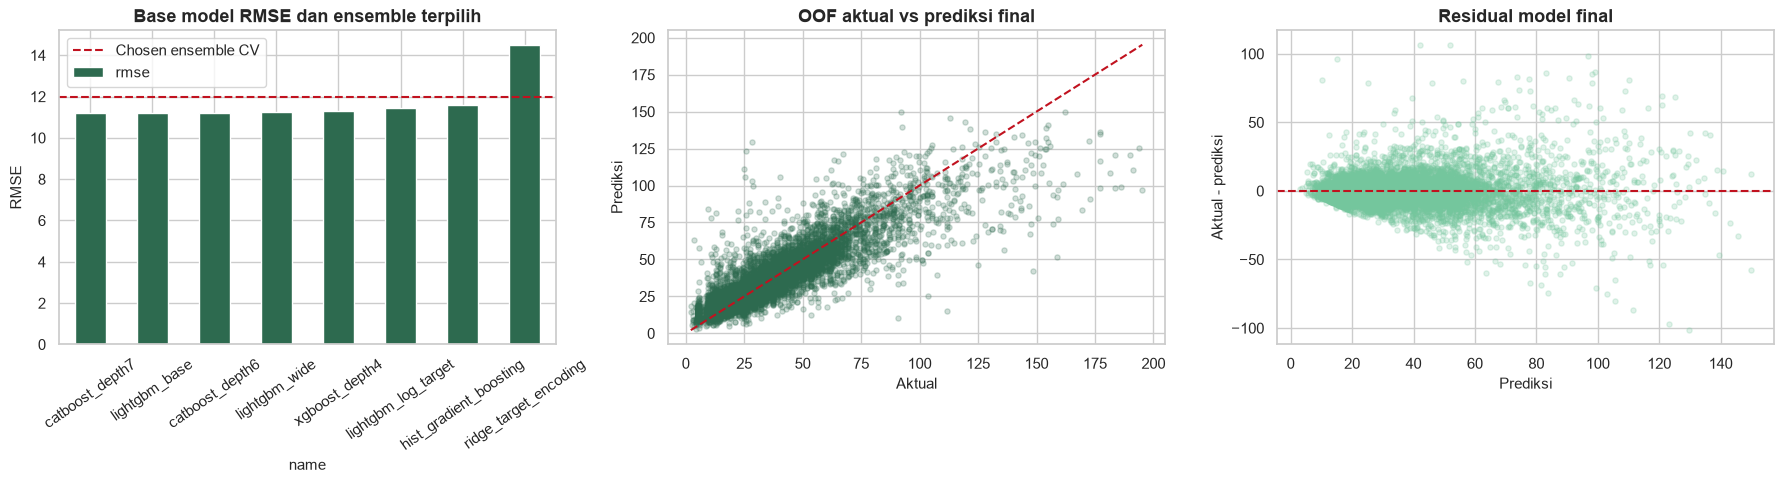

In [15]:
band_b_cols = [c for c in train.columns if c.startswith("spectral_band_B_PC_")]
residuals = y_values - oof_pred
band_b_available = train[band_b_cols].notna().any(axis=1)
band_b_metrics = pd.DataFrame([
    {
        "kelompok": "Band B tersedia",
        "n": band_b_available.sum(),
        **regression_metrics(y_values[band_b_available.to_numpy()], oof_pred[band_b_available.to_numpy()]),
    },
    {
        "kelompok": "Band B tidak tersedia",
        "n": (~band_b_available).sum(),
        **regression_metrics(y_values[(~band_b_available).to_numpy()], oof_pred[(~band_b_available).to_numpy()]),
    },
]).set_index("kelompok")
print_table("Error OOF final untuk sampel dengan Band B tersedia dan tidak tersedia.", band_b_metrics)

_, axes = plt.subplots(1, 3, figsize=(18, 5))
base_model_metrics["rmse"].sort_values().plot(kind="bar", color=GREEN, ax=axes[0])
axes[0].axhline(chosen_cv_rmse, color=RED, ls="--", label="Chosen ensemble CV")
axes[0].set_title("Base model RMSE dan ensemble terpilih")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend()

axes[1].scatter(y_values, oof_pred, alpha=0.22, s=14, color=GREEN)
lims = [min(y_values.min(), oof_pred.min()), max(y_values.max(), oof_pred.max())]
axes[1].plot(lims, lims, "--", color=RED)
axes[1].set_title("OOF aktual vs prediksi final")
axes[1].set_xlabel("Aktual")
axes[1].set_ylabel("Prediksi")

axes[2].scatter(oof_pred, residuals, alpha=0.22, s=14, color=LIGHT_GREEN)
axes[2].axhline(0, ls="--", color=RED)
axes[2].set_title("Residual model final")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("Aktual - prediksi")
plt.tight_layout()
plt.show()


In [16]:
best_base_name = base_model_metrics["rmse"].idxmin()
best_base_rmse = float(base_model_metrics.loc[best_base_name, "rmse"])
dummy_rmse = float(dummy_metrics["RMSE"])
stack_oof_rmse = float(final_oof_metrics["RMSE"])
oof_optimism_gap = chosen_cv_rmse - stack_oof_rmse
best_base_gap = chosen_cv_rmse - best_base_rmse

print(f"Dummy median RMSE                         : {dummy_rmse:.3f}")
print(f"Best base model                           : {best_base_name} (RMSE {best_base_rmse:.3f})")
print(f"Chosen ensemble strategy                  : {chosen_strategy_name}")
print(f"Nested GroupKFold RMSE ensemble terpilih  : {chosen_cv_rmse:.3f}")
print(f"Full-stack OOF RMSE                       : {stack_oof_rmse:.3f}")
print(f"Optimism gap full-stack OOF vs nested CV  : {oof_optimism_gap:.3f}")
print(f"Gap ensemble CV vs best base model        : {best_base_gap:.3f}")


Dummy median RMSE                         : 24.128
Best base model                           : catboost_depth7 (RMSE 11.200)
Chosen ensemble strategy                  : stack_ridge
Nested GroupKFold RMSE ensemble terpilih  : 11.988
Full-stack OOF RMSE                       : 11.025
Optimism gap full-stack OOF vs nested CV  : 0.964
Gap ensemble CV vs best base model        : 0.788


## Jawaban Soal 2

Model final **tidak underfit** dan **tidak menunjukkan overfit berat**.

Terbukti, output code di atas menunjukkan RMSE baseline median jauh lebih buruk daripada model final. Artinya model mampu mempelajari pola data secara bermakna, sehingga bukan underfit.

Untuk overfit, acuan utama adalah **Nested GroupKFold RMSE**, bukan full-stack OOF RMSE yang lebih optimistis. Nilai Nested GroupKFold masih dekat dengan catatan skor publik Kaggle (11.89198), sehingga tidak ada tanda kuat bahwa model hanya bagus di data training tetapi gagal pada data test.

Mitigasinya adalah target encoding fold-safe, validasi berbasis source_id, ensemble beberapa model, stack Ridge yang diregularisasi, dan koreksi konservatif pada prediksi ekstrem.


# Soal 3: Distribusi geografis dan ekosistem dominan

> **Apakah ada pola distribusi kandungan organik tanah yang berbeda secara signifikan antar wilayah
> geografis? Berdasarkan pola tersebut, kira-kira kondisi ekosistem seperti apa yang paling dominan
> dalam dataset ini? Jelaskan reasoning Anda berdasarkan informasi ekologis dan tutupan lahan yang
> terlihat!**

## Pendekatan dan asumsi

Menghitung ringkasan target per zona macro, menguji perbedaan dengan Kruskal-Wallis, melakukan uji pasangan dengan koreksi Holm, lalu menampilkan komposisi bioma dan tutupan lahan.


In [17]:
macro_summary = (
    train.groupby("geo_zone_macro")[TARGET]
    .agg(count="size", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)
macro_groups = [
    group[TARGET].values for _, group in train.groupby("geo_zone_macro")
]
kw = stats.kruskal(*macro_groups)
k_macro = train["geo_zone_macro"].nunique()
epsilon_squared = (kw.statistic - k_macro + 1) / (len(train) - k_macro)

posthoc_rows = []
for zone_a, zone_b in combinations(sorted(train["geo_zone_macro"].unique()), 2):
    a = train.loc[train["geo_zone_macro"] == zone_a, TARGET]
    b = train.loc[train["geo_zone_macro"] == zone_b, TARGET]
    result = stats.mannwhitneyu(a, b, alternative="two-sided")
    rank_biserial = 2 * result.statistic / (len(a) * len(b)) - 1
    posthoc_rows.append({
        "zona_A": zone_a,
        "zona_B": zone_b,
        "U": result.statistic,
        "p_raw": result.pvalue,
        "rank_biserial": rank_biserial,
    })
posthoc = pd.DataFrame(posthoc_rows)
posthoc["p_holm"] = holm_adjust(posthoc["p_raw"])
posthoc["signifikan_5pct"] = posthoc["p_holm"] < 0.05

dominant_biome = train["biome"].value_counts().idxmax()
dominant_cover = train["land_cover_type"].value_counts().idxmax()
highest_macro = macro_summary.index[0]
lowest_macro = macro_summary.index[-1]

print_table("Statistik kandungan organik per zona macro.", macro_summary)
print(
    f"Kruskal-Wallis H={kw.statistic:.3f}, p={kw.pvalue:.3e}, "
    f"epsilon-squared={epsilon_squared:.3f}"
)
print(f"Zona mean tertinggi: {highest_macro} ({macro_summary.loc[highest_macro, 'mean']:.2f})")
print(f"Zona mean terendah : {lowest_macro} ({macro_summary.loc[lowest_macro, 'mean']:.2f})")
print(f"Bioma dominan berdasarkan jumlah sampel: {dominant_biome}")
print(f"Tutupan lahan dominan berdasarkan jumlah sampel: {dominant_cover}")
print_table("Uji pasangan antar zona setelah koreksi Holm.", posthoc.sort_values("p_holm"))


Statistik kandungan organik per zona macro.
                count    mean  median     std
geo_zone_macro                               
S                1022 57.2668 55.7897 36.4520
NE                512 42.3672 35.1922 31.2203
MW               2930 34.5005 29.1245 20.5871
N                 979 34.3947 30.7426 19.6251
SE               5767 29.0897 24.2705 17.8190

Kruskal-Wallis H=747.418, p=1.879e-160, epsilon-squared=0.066
Zona mean tertinggi: S (57.27)
Zona mean terendah : SE (29.09)
Bioma dominan berdasarkan jumlah sampel: Mata Atlantica
Tutupan lahan dominan berdasarkan jumlah sampel: Seasonal Semideciduous Forest
Uji pasangan antar zona setelah koreksi Holm.
  zona_A zona_B              U  p_raw  rank_biserial  p_holm  signifikan_5pct
9      S     SE 4,324,293.0000 0.0000         0.4674  0.0000             True
2     MW      S   943,808.0000 0.0000        -0.3696  0.0000             True
5      N      S   316,783.5000 0.0000        -0.3668  0.0000             True
3     MW     SE

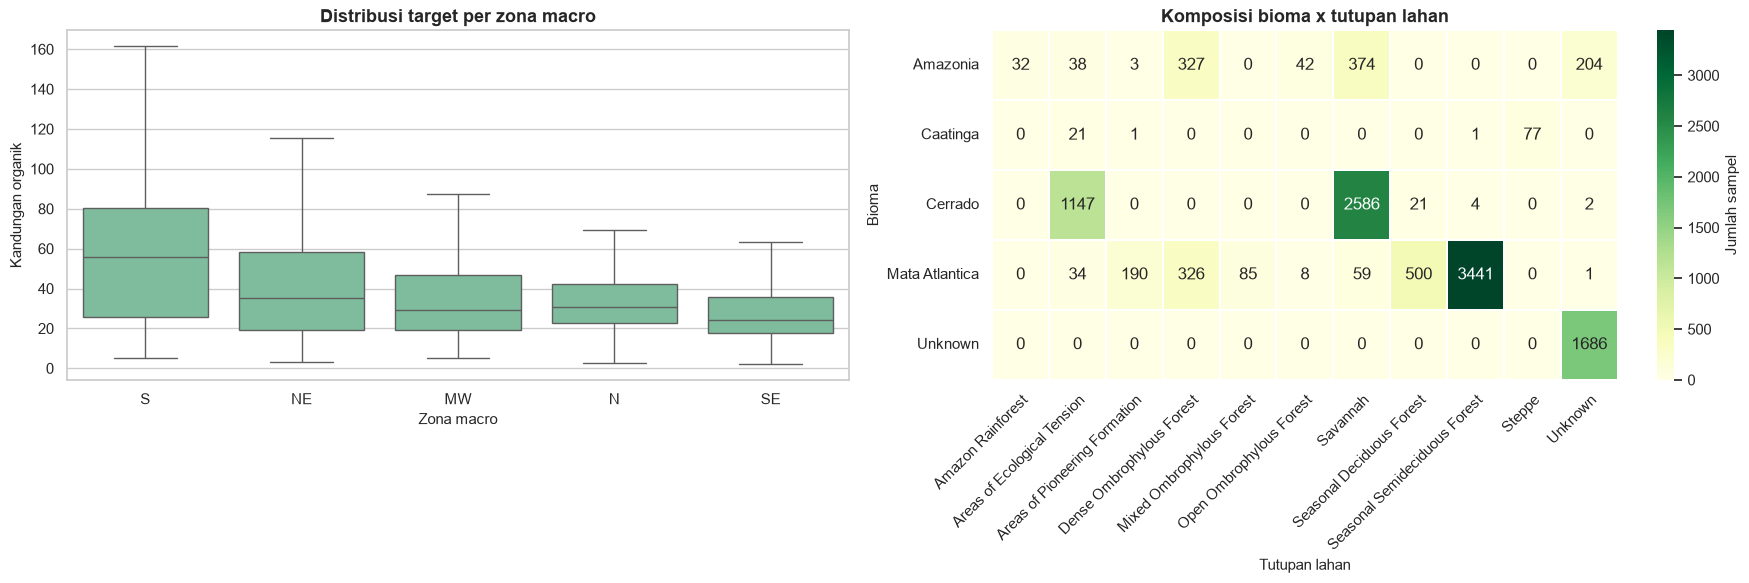

Jumlah sampel dan nilai target per tutupan lahan.
                               count    mean  median
land_cover_type                                     
Seasonal Semideciduous Forest   3446 27.6678 22.6524
Savannah                        3019 35.0505 30.7426
Unknown                         1893 34.1216 27.5065
Areas of Ecological Tension     1240 33.1872 28.0728
Dense Ombrophylous Forest        653 35.4323 27.5065
Seasonal Deciduous Forest        521 69.1805 65.1257
Areas of Pioneering Formation    194 22.8572 22.6524
Mixed Ombrophylous Forest         85 74.2486 77.8434
Steppe                            77 45.0983 38.2664
Open Ombrophylous Forest          50 42.1394 36.1630
Amazon Rainforest                 32 10.2256  8.7014



In [18]:
biome_land_mean = train.pivot_table(
    index="biome", columns="land_cover_type", values=TARGET, aggfunc="mean"
)
biome_land_count = train.pivot_table(
    index="biome", columns="land_cover_type", values=TARGET, aggfunc="size",
    fill_value=0
)

_, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(
    data=train, x="geo_zone_macro", y=TARGET,
    order=macro_summary.index, showfliers=False,
    color=LIGHT_GREEN, ax=axes[0]
)
axes[0].set_title("Distribusi target per zona macro")
axes[0].set_xlabel("Zona macro")
axes[0].set_ylabel("Kandungan organik")

sns.heatmap(
    biome_land_count, cmap="YlGn", annot=True, fmt=".0f",
    linewidths=0.3, ax=axes[1], cbar_kws={"label": "Jumlah sampel"}
)
axes[1].set_title("Komposisi bioma x tutupan lahan")
axes[1].set_xlabel("Tutupan lahan")
axes[1].set_ylabel("Bioma")
axes[1].tick_params(axis="y", rotation=0)
axes[1].tick_params(axis="x", rotation=45)
plt.setp(
    axes[1].get_xticklabels(),
    ha="right",
    rotation_mode="anchor",
)
plt.tight_layout()
plt.show()

landcover_summary = (
    train.groupby("land_cover_type")[TARGET]
    .agg(count="size", mean="mean", median="median")
    .sort_values("count", ascending=False)
)
print_table("Jumlah sampel dan nilai target per tutupan lahan.", landcover_summary)


## Jawaban Soal 3

**Ya, kandungan organik tanah berbeda signifikan antar zona geografis.** Hal ini didukung oleh uji **Kruskal-Wallis** dengan p-value sangat kecil, sehingga perbedaan distribusi target antar **geo_zone_macro** tidak dapat dianggap sebagai variasi acak.

Dominasi ekosistem dilihat dari **jumlah sampel**. Pada **land_cover_type**, kategori terbesar adalah **Seasonal Semideciduous Forest** sebanyak **3.446 sampel** dengan mean **27,67** dan median **22,65**, disusul **Savannah** sebanyak **3.019 sampel** dengan mean **35,05** dan median **30,74**. Ini menunjukkan dataset paling kuat merepresentasikan hutan semi-deciduous Atlantik dan savana tropis Brasil.

Namun, kategori dengan mean tertinggi belum tentu paling representatif. Misalnya, **Mixed Ombrophylous Forest** memiliki mean **74,25**, tetapi hanya **85 sampel**, sedangkan **Amazon Rainforest** memiliki mean **10,23** dengan hanya **32 sampel**. Karena itu, interpretasi kategori kecil perlu hati-hati.

Secara umum, hasil ini menunjukkan adanya **asosiasi** antara zona/tutupan lahan dan kandungan organik tanah, tetapi belum membuktikan hubungan kausal langsung.

# Soal 4: Korelasi antar tingkat wilayah dan rasio rata-rata

> **Apakah ada korelasi kandungan organik tanah antar tingkat wilayah geografis? Berapa rasio
> perbandingan rata-rata kandungan organik antar wilayah tersebut, dan bagaimana ini memengaruhi
> pendekatan pemodelan Anda?**

## Pendekatan dan asumsi

Menghitung mean, median, ukuran sampel, bootstrap 95% CI, korelasi antar level wilayah, dan rasio mean maksimum/minimum. Rasio hanya memakai kelompok dengan minimal 20 sampel agar tidak didominasi kelompok kecil.


In [19]:
geo_levels = ["geo_zone_macro", "geo_zone_meso", "geo_zone_micro"]
geo_detail_tables = {}
geo_summary_rows = []
geo_mean_encoded = pd.DataFrame(index=train.index)

for level_index, level in enumerate(geo_levels):
    rows = []
    for group_name, group in train.groupby(level):
        ci_low, ci_high = bootstrap_mean_ci(
            group[TARGET], n_boot=400,
            seed=RANDOM_STATE + level_index + len(group)
        )
        rows.append({
            "group": group_name,
            "count": len(group),
            "mean": group[TARGET].mean(),
            "median": group[TARGET].median(),
            "ci_low": ci_low,
            "ci_high": ci_high,
        })
    detail = pd.DataFrame(rows).sort_values("mean")
    stable = detail.query("count >= 20")
    geo_detail_tables[level] = detail
    geo_summary_rows.append({
        "level": level,
        "n_group": len(detail),
        "n_group_stable": len(stable),
        "min_group": stable.iloc[0]["group"],
        "min_mean": stable.iloc[0]["mean"],
        "max_group": stable.iloc[-1]["group"],
        "max_mean": stable.iloc[-1]["mean"],
        "max_min_ratio": stable.iloc[-1]["mean"] / stable.iloc[0]["mean"],
        "eta_squared": eta_squared(train, level),
    })
    group_means = train.groupby(level)[TARGET].mean()
    geo_mean_encoded[level] = train[level].map(group_means)

geo_summary = pd.DataFrame(geo_summary_rows).set_index("level")
geo_corr = geo_mean_encoded.corr(method="spearman")
print_table("Rasio mean maksimum/minimum dan ukuran efek tiap level wilayah.", geo_summary)
print_table("Korelasi Spearman antar level wilayah.", geo_corr)
print_table("Detail zona macro beserta bootstrap confidence interval.", geo_detail_tables["geo_zone_macro"])

Rasio mean maksimum/minimum dan ukuran efek tiap level wilayah.
                n_group  n_group_stable min_group  min_mean max_group  max_mean  max_min_ratio  eta_squared
level                                                                                                      
geo_zone_macro        5               5        SE   29.0897         S   57.2668         1.9686       0.1208
geo_zone_meso        23              18  State_18   18.8800  State_03   72.9516         3.8640       0.2747
geo_zone_micro       50              23   Loc_023   10.2256   Loc_005   86.7856         8.4871       0.2734

Korelasi Spearman antar level wilayah.
                geo_zone_macro  geo_zone_meso  geo_zone_micro
geo_zone_macro          1.0000         0.6201          0.3257
geo_zone_meso           0.6201         1.0000          0.5361
geo_zone_micro          0.3257         0.5361          1.0000

Detail zona macro beserta bootstrap confidence interval.
  group  count    mean  median  ci_low  ci_high
4 

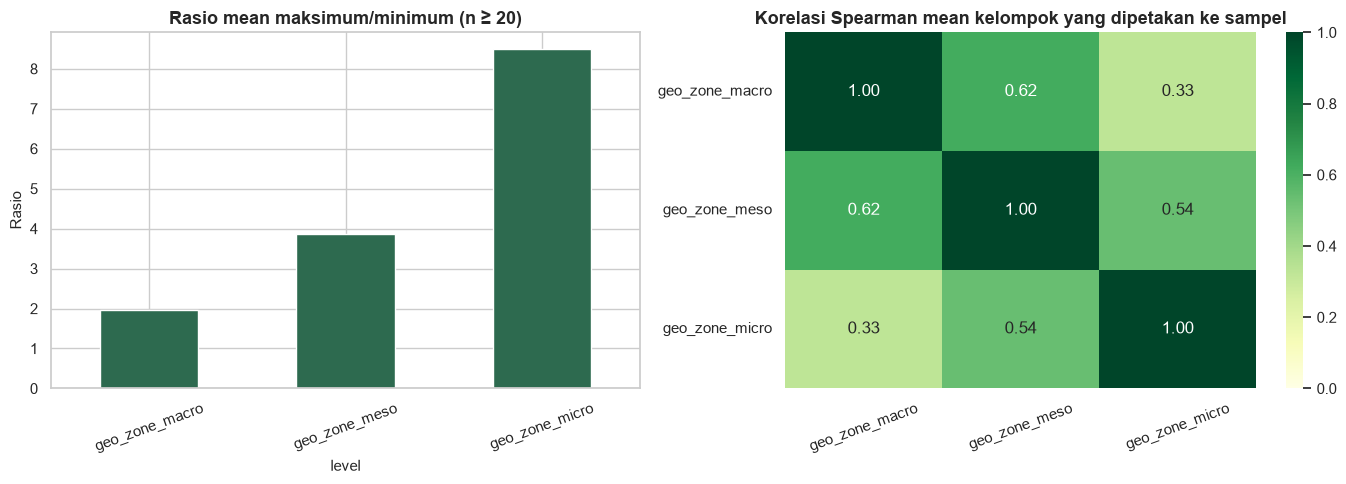

In [20]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))
geo_summary["max_min_ratio"].plot(kind="bar", color=GREEN, ax=axes[0])
axes[0].set_title("Rasio mean maksimum/minimum (n ≥ 20)")
axes[0].set_ylabel("Rasio")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(
    geo_corr, annot=True, fmt=".2f", cmap="YlGn", vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title("Korelasi Spearman mean kelompok yang dipetakan ke sampel")
axes[1].tick_params(axis="y", rotation=0)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Jawaban Soal 4

**Ada korelasi positif antar tingkat wilayah, tetapi level lokal tetap membawa informasi tambahan.** Karena itu, fitur **geo_zone_macro**, **geo_zone_meso**, dan **geo_zone_micro** tetap perlu dipertahankan.

Heatmap menunjukkan korelasi Spearman antara **macro–meso** sebesar **0,62**, **meso–micro** sebesar **0,54**, dan **macro–micro** hanya **0,33**. Artinya, hubungan antar level wilayah ada, tetapi tidak sempurna, terutama antara level macro dan micro.

Visualisasi rasio mean maksimum/minimum juga menunjukkan variasi target makin besar pada level yang lebih detail: **geo_zone_macro ≈ 1,9**, **geo_zone_meso ≈ 3,8**, dan **geo_zone_micro ≈ 8,5**. Ini berarti level micro menangkap variasi kandungan organik tanah yang lebih spesifik.

Dampaknya, fitur wilayah penting untuk modeling, tetapi evaluasi tetap perlu memakai validasi berbasis **group/spatial** agar model tidak sekadar menghafal pola lokasi.

# Soal 5a: Kondisi acidity dan kapasitas tukar kation

> **Berapa rata-rata kandungan organik tanah dari tiap ekosistem ketika tingkat keasaman tanah berada
> di bawah persentil 25 dan kapasitas tukar kation berada di bawah rata-rata? Apa insight yang bisa
> didapat dari hal ini?**

## Pendekatan dan asumsi

Memfilter sampel dengan acidity index di bawah persentil 25 dan kapasitas tukar kation di bawah rata-rata. Setelah itu, rata-rata target dihitung per bioma, lengkap dengan median, standard deviation, dan bootstrap 95% CI.


Memfilter sampel acidity rendah dan KTK di bawah rata-rata, lalu meringkas target per bioma.
P25 acidity index = 12.8805
Mean cation exchange capacity = 169.1421
Jumlah sampel hasil filter = 388
Ringkasan target per bioma setelah filter.
            biome  count    mean  median     std  ci_low  ci_high  cukup_stabil_n_ge_20
4         Unknown      1 43.6868 43.6868     NaN 43.6868  43.6868                 False
0        Amazonia    197 27.6124 27.5065  6.7311 26.5948  28.5993                  True
2         Cerrado      2 24.2705 24.2705  0.0000 24.2705  24.2705                 False
3  Mata Atlantica    186 21.3180 21.0344 10.0405 20.0135  22.8990                  True
1        Caatinga      2 19.9827 19.9827  1.2585 19.0928  20.8726                 False



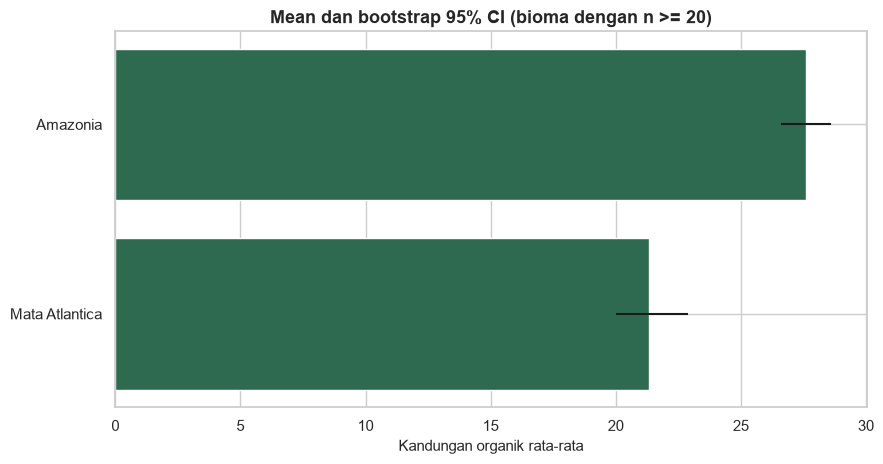

In [33]:
acidity_p25 = train["property_acidity_index"].quantile(0.25)
cec_mean = train["cation_exchange_capacity"].mean()
subset_5a = train[
    (train["property_acidity_index"] < acidity_p25)
    & (train["cation_exchange_capacity"] < cec_mean)
].copy()

q5a_rows = []
for index, (biome, group) in enumerate(subset_5a.groupby("biome")):
    ci_low, ci_high = bootstrap_mean_ci(
        group[TARGET], n_boot=1000, seed=RANDOM_STATE + index
    )
    q5a_rows.append({
        "biome": biome,
        "count": len(group),
        "mean": group[TARGET].mean(),
        "median": group[TARGET].median(),
        "std": group[TARGET].std(),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cukup_stabil_n_ge_20": len(group) >= 20,
    })
q5a = pd.DataFrame(q5a_rows).sort_values("mean", ascending=False)

print("Memfilter sampel acidity rendah dan KTK di bawah rata-rata, lalu meringkas target per bioma.")
print(f"P25 acidity index = {acidity_p25:.4f}")
print(f"Mean cation exchange capacity = {cec_mean:.4f}")
print(f"Jumlah sampel hasil filter = {len(subset_5a)}")
print_table("Ringkasan target per bioma setelah filter.", q5a)

stable_q5a = q5a.query("count >= 20").sort_values("mean")
plt.figure(figsize=(9, 4.8))
xerr = np.vstack([
    stable_q5a["mean"] - stable_q5a["ci_low"],
    stable_q5a["ci_high"] - stable_q5a["mean"],
])
plt.barh(stable_q5a["biome"], stable_q5a["mean"], color=GREEN, xerr=xerr)
plt.title("Mean dan bootstrap 95% CI (bioma dengan n >= 20)")
plt.xlabel("Kandungan organik rata-rata")
plt.tight_layout()
plt.show()


## Jawaban Soal 5a

**Ketika `acidity` berada di bawah persentil 25 dan KTK berada di bawah rata-rata, hanya dua bioma yang memenuhi batas sampel `n ≥ 20`, yaitu Amazonia dan Mata Atlantica.** Dari visualisasi, rata-rata kandungan organik tanah pada **Amazonia** sekitar **27,6**, sedangkan **Mata Atlantica** sekitar **21,3**.

Bootstrap **95% confidence interval** juga menunjukkan bahwa estimasi Amazonia berada kira-kira pada rentang **26,5–28,7**, sementara Mata Atlantica berada sekitar **20,0–22,8**. Karena rentang CI keduanya tidak banyak bertumpang tindih, Amazonia cenderung memiliki kandungan organik lebih tinggi dibanding Mata Atlantica pada kondisi tanah dengan acidity rendah dan KTK rendah.

Insight utamanya adalah kondisi kimia tanah yang sama tidak menghasilkan kandungan organik yang seragam antar bioma. Faktor ekosistem tetap penting, sehingga interpretasi kandungan organik perlu mempertimbangkan konteks bioma, tutupan lahan, tekstur tanah, dan sumber data. Namun, hasil ini tetap terbatas pada subset data yang lolos filter dan hanya mencakup bioma dengan jumlah sampel memadai.

# Soal 5b: Outlier kombinasi tutupan lahan dan wilayah

> **Apakah ada kombinasi jenis tutupan lahan dan wilayah geografis tertentu yang memiliki nilai
> kandungan organik yang dapat dianggap sebagai outlier? Jelaskan justifikasi Anda!**

## Pendekatan dan asumsi

Mencari outlier di dalam setiap kombinasi `land_cover_type x geo_zone_macro`. Definisi utama memakai aturan IQR, lalu dibandingkan dengan robust z-score berbasis MAD. Kombinasi kecil disaring dengan minimum 20 sampel.


In [34]:
combo = train.groupby(["land_cover_type", "geo_zone_macro"])[TARGET].agg(
    n="size",
    mean="mean",
    median="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    mad=lambda s: stats.median_abs_deviation(s, scale=1, nan_policy="omit"),
).reset_index()
combo["iqr"] = combo["q3"] - combo["q1"]
combo["lower_iqr"] = combo["q1"] - 1.5 * combo["iqr"]
combo["upper_iqr"] = combo["q3"] + 1.5 * combo["iqr"]

outlier_data = train.merge(
    combo, on=["land_cover_type", "geo_zone_macro"], how="left"
)
outlier_data["outlier_iqr"] = (
    (outlier_data[TARGET] < outlier_data["lower_iqr"])
    | (outlier_data[TARGET] > outlier_data["upper_iqr"])
)
outlier_data["robust_z"] = np.where(
    outlier_data["mad"] > 0,
    0.6745 * (outlier_data[TARGET] - outlier_data["median"])
    / outlier_data["mad"],
    0,
)
outlier_data["outlier_mad"] = outlier_data["robust_z"].abs() > 3.5

outlier_summary = (
    outlier_data.groupby(["land_cover_type", "geo_zone_macro"])
    .agg(
        n=(TARGET, "size"),
        mean_target=(TARGET, "mean"),
        outlier_iqr=("outlier_iqr", "sum"),
        outlier_mad=("outlier_mad", "sum"),
        max_target=(TARGET, "max"),
    )
    .reset_index()
)
outlier_summary["iqr_rate"] = outlier_summary["outlier_iqr"] / outlier_summary["n"]
outlier_summary["mad_rate"] = outlier_summary["outlier_mad"] / outlier_summary["n"]
outlier_summary["kombinasi"] = (
    outlier_summary["land_cover_type"] + " | "
    + outlier_summary["geo_zone_macro"]
)
reliable_outliers = (
    outlier_summary.query("n >= 20")
    .sort_values(["iqr_rate", "outlier_iqr"], ascending=False)
)
print_table("Kombinasi tutupan lahan dan zona macro dengan outlier rate tertinggi.", reliable_outliers, max_rows=15)


Kombinasi tutupan lahan dan zona macro dengan outlier rate tertinggi.
                  land_cover_type geo_zone_macro     n  mean_target  outlier_iqr  outlier_mad  max_target  iqr_rate  mad_rate                           kombinasi
0               Amazon Rainforest             NE    32      10.2256            4            4     25.6188    0.1250    0.1250              Amazon Rainforest | NE
25  Seasonal Semideciduous Forest             SE  3150      26.0721          235          187    155.3309    0.0746    0.0594  Seasonal Semideciduous Forest | SE
27                        Unknown             MW   541      40.8451           38           28    177.0610    0.0702    0.0518                        Unknown | MW
2     Areas of Ecological Tension              N    38      56.7401            2            0    131.0604    0.0526    0.0000     Areas of Ecological Tension | N
26                         Steppe             NE    77      45.0983            3            2    185.9440    0.0390    0

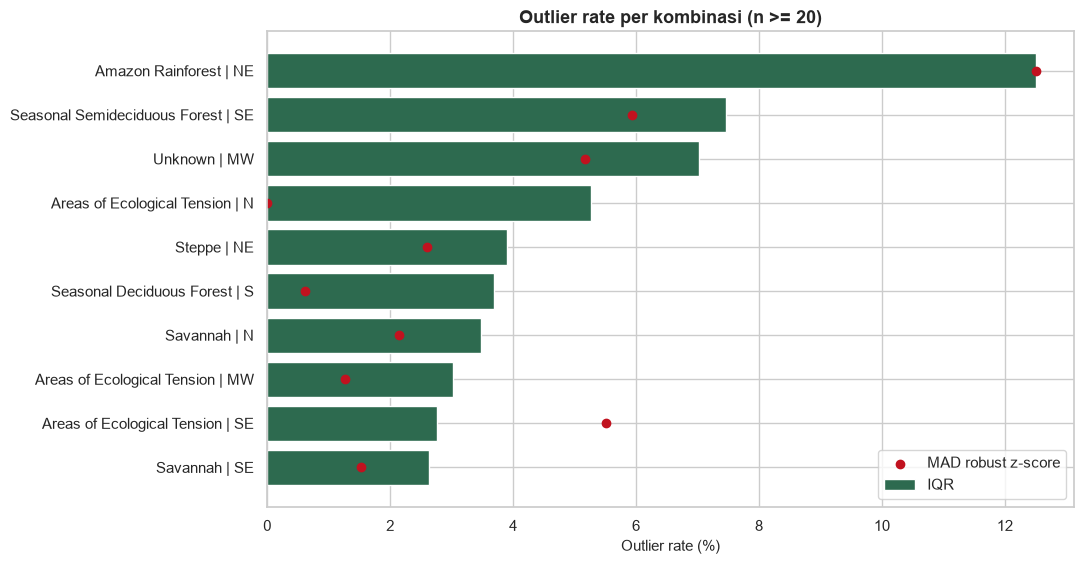

Contoh sampel individual yang melewati batas outlier IQR kelompoknya.
         sample_id            land_cover_type geo_zone_macro  property_organic_content  lower_iqr  upper_iqr  robust_z
1453   train_01454  Dense Ombrophylous Forest             NE                  193.6782   -69.0737   155.2500    4.7283
10245  train_10246  Seasonal Deciduous Forest              S                  189.7949   -15.1326   151.6863    3.8915
6873   train_06874                     Steppe             NE                  185.9440   -14.5623    98.0526    7.4711
7562   train_07563  Seasonal Deciduous Forest              S                  183.4037   -15.1326   151.6863    3.6881
669    train_00670  Seasonal Deciduous Forest              S                  183.4037   -15.1326   151.6863    3.6881
9218   train_09219                   Savannah             SE                  181.2194   -12.9442    80.2543    9.3323
4605   train_04606                    Unknown             MW                  177.0610   -33.1696

In [35]:
top_outliers = reliable_outliers.head(10).sort_values("iqr_rate")
plt.figure(figsize=(11, 5.8))
plt.barh(
    top_outliers["kombinasi"], top_outliers["iqr_rate"] * 100,
    color=GREEN, label="IQR"
)
plt.scatter(
    top_outliers["mad_rate"] * 100,
    top_outliers["kombinasi"],
    color=RED, label="MAD robust z-score"
)
plt.title("Outlier rate per kombinasi (n >= 20)")
plt.xlabel("Outlier rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

individual_outliers = (
    outlier_data.loc[
        outlier_data["outlier_iqr"] & (outlier_data["n"] >= 20),
        ["sample_id", "land_cover_type", "geo_zone_macro", TARGET,
         "lower_iqr", "upper_iqr", "robust_z"]
    ]
    .sort_values(TARGET, ascending=False)
    .head(15)
)
print_table("Contoh sampel individual yang melewati batas outlier IQR kelompoknya.", individual_outliers)


## Jawaban Soal 5b

**Ya, ada kombinasi tutupan lahan dan wilayah yang memiliki proporsi outlier lebih tinggi. Namun outlier tersebut tidak otomatis berarti data salah.**

Justifikasinya memakai batas IQR di dalam masing-masing kelompok. Dengan cara ini, kelompok yang memang punya rata-rata alami lebih tinggi tidak langsung dianggap outlier hanya karena berbeda dari populasi global.

Minimum 20 sampel dipakai agar kuartil kelompok tidak terlalu tidak stabil. Perbandingan dengan MAD membantu melihat apakah temuan sensitif terhadap definisi outlier.

Nilai ekstrem bisa merepresentasikan kondisi mikro-lokasi, tanah organik, drainase, pengelolaan, atau perbedaan laboratorium. Langkah yang lebih tepat adalah audit metadata dan analisis residual sebelum memutuskan menghapus data.


# Soal 6: Korelasi tinggi dan multicollinearity

> **Apakah ada pasangan variabel yang berkorelasi tinggi? Apakah ada efek multicollinearity yang perlu
> diatasi dalam modeling?**

## Pendekatan dan asumsi

Menghitung korelasi Spearman untuk fitur numerik, mengambil pasangan dengan korelasi absolut tinggi, lalu menghitung VIF pada subset fitur tanah utama. Spearman dipilih karena distribusi target dan beberapa fitur tidak normal.


Pasangan fitur numerik dengan korelasi Spearman absolut minimal 0.70.
                                                 spearman_r  abs_r
property_particle_coarse property_particle_fine     -0.9147 0.9147
cation_Ca                cation_Mg                   0.8582 0.8582
property_acidity_index   cation_Ca                   0.7214 0.7214



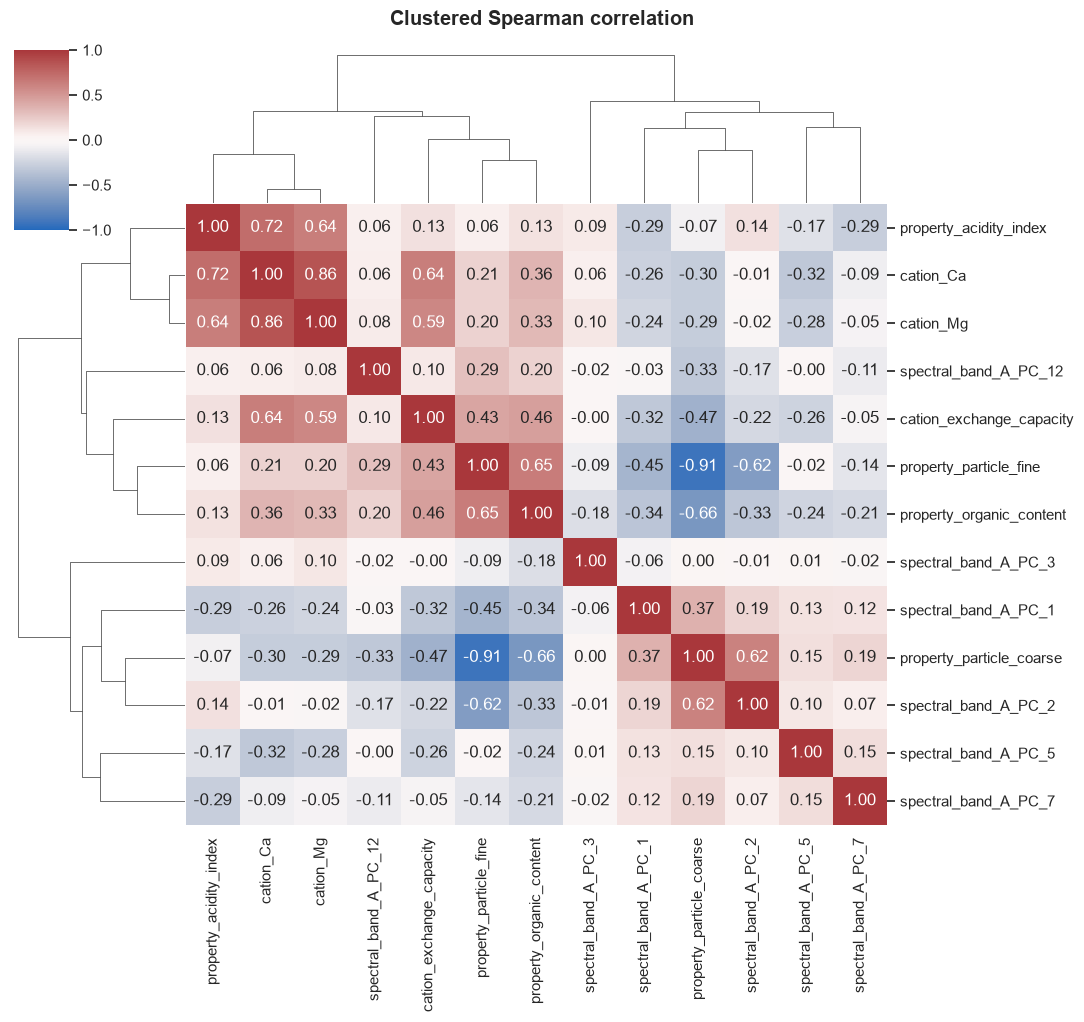

In [36]:
numeric = train.select_dtypes(include=np.number)
spearman = numeric.corr(method="spearman")
upper = np.triu(np.ones(spearman.shape), k=1).astype(bool)
corr_pairs = spearman.where(upper).stack().rename("spearman_r").to_frame()
corr_pairs["abs_r"] = corr_pairs["spearman_r"].abs()
high_corr_pairs = corr_pairs.query("abs_r >= 0.70").sort_values(
    "abs_r", ascending=False
)
print_table("Pasangan fitur numerik dengan korelasi Spearman absolut minimal 0.70.", high_corr_pairs)

selected_corr_features = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity", "spectral_band_A_PC_1",
    "spectral_band_A_PC_2", "spectral_band_A_PC_3",
    "spectral_band_A_PC_5", "spectral_band_A_PC_7",
    "spectral_band_A_PC_12", TARGET,
]
cluster = sns.clustermap(
    train[selected_corr_features].corr(method="spearman"),
    cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", figsize=(11, 10)
)
cluster.fig.suptitle("Clustered Spearman correlation", y=1.02, fontweight="bold")
plt.show()


In [37]:
vif_cols = [
    "property_particle_coarse", "property_particle_fine",
    "property_acidity_index", "cation_Ca", "cation_Mg",
    "cation_exchange_capacity",
]
vif_matrix = SimpleImputer(strategy="median").fit_transform(train[vif_cols])
vif_matrix = StandardScaler().fit_transform(vif_matrix)

vif_rows = []
for i, feature in enumerate(vif_cols):
    other = np.arange(len(vif_cols)) != i
    feature_r2 = LinearRegression().fit(
        vif_matrix[:, other], vif_matrix[:, i]
    ).score(vif_matrix[:, other], vif_matrix[:, i])
    vif_rows.append({
        "feature": feature,
        "VIF": 1 / (1 - feature_r2),
    })
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
condition_number = np.linalg.cond(vif_matrix)
print_table("VIF untuk subset fitur tanah utama.", vif_table)
print(f"Condition number = {condition_number:.3f}")


VIF untuk subset fitur tanah utama.
                    feature    VIF
0  property_particle_coarse 6.0290
1    property_particle_fine 5.7258
3                 cation_Ca 2.9186
4                 cation_Mg 2.4334
5  cation_exchange_capacity 1.6396
2    property_acidity_index 1.0850

Condition number = 5.568


## Jawaban Soal 6

**Ada multikolinearitas yang jelas, terutama pada fitur tekstur tanah dan beberapa fitur kimia. Ini penting untuk interpretasi, tetapi tidak membatalkan penggunaan model tree boosting dan ensemble.**

Pasangan variabel dengan korelasi tinggi menunjukkan bahwa sebagian fitur membawa informasi yang tumpang tindih. Dampaknya paling besar pada model linear, karena koefisien bisa menjadi tidak stabil dan sulit ditafsirkan secara individual.

Untuk model tree boosting seperti HistGradientBoosting, multikolinearitas biasanya tidak merusak training dengan cara yang sama seperti regresi linear. Namun interpretasi feature importance tetap harus hati-hati karena kontribusi dapat terbagi di antara fitur yang saling berkorelasi.

PLS tetap relevan sebagai baseline untuk data spektral yang kolinear, sedangkan model utama mempertahankan fitur komposisional seperti `fine_fraction` agar model tetap memiliki representasi tanah yang informatif.


# Soal 7: Feature engineering

> **Fitur baru apa saja yang Anda buat melalui proses feature engineering? Jelaskan bagaimana fitur
> tersebut meningkatkan pemahaman model terhadap pola kandungan organik tanah!**


In [41]:
raw_input_cols = train.drop(columns=[TARGET, "sample_id"], errors="ignore").columns.tolist()
raw_input_set = set(raw_input_cols)

missingness_features = [
    c for c in [
        "missing_total",
        "band_B_available_actual_num",
        "band_B_missing_count",
        "coord_available_num",
        "chem_missing_count",
    ]
    if c in X.columns
]
spectral_summary_features = [
    c for c in X.columns
    if (
        c in ["A_mean", "A_std", "A_min", "A_max", "A_l2", "A_abs_sum", "A_max_abs",
              "B_mean", "B_std", "B_min", "B_max", "B_l2", "B_abs_sum", "B_max_abs"]
        or c.endswith("_abs")
        or c.endswith("_sq")
    )
]
soil_chemistry_features = [
    c for c in [
        "particle_total",
        "fine_fraction",
        "fine_to_coarse",
        "fine_minus_coarse",
        "base_cation_sum",
        "ca_mg_ratio",
        "mg_ca_ratio",
        "base_saturation_proxy",
        "ca_cec_ratio",
        "mg_cec_ratio",
        "cec_per_fine",
        "acidity_x_cec",
        "acidity_per_cec",
        "log1p_cation_exchange_capacity",
        "log1p_cation_Ca",
        "log1p_cation_Mg",
        "log1p_property_acidity_index",
    ]
    if c in X.columns
]
geography_features = [
    c for c in [
        "abs_latitude",
        "abs_longitude",
        "lat_lon_sum",
        "lat_lon_diff",
        "lat_lon_prod",
        "lat_round_1",
        "lon_round_1",
    ]
    if c in X.columns
]
interaction_features = [
    c for c in [
        "geo_hierarchy",
        "biome_landcover",
        "source_micro",
        "source_landcover",
        "meso_landcover",
        "landcover_rock",
        "source_rock",
        "latlon_grid1",
    ]
    if c in X.columns
]
frequency_features = [c for c in X.columns if c.endswith("_freq")]
encoded_categorical_features = [
    c for c in cat_str_cols
    if c in X.columns and c not in raw_input_set
]
raw_shadow_features = RAW_COLS
te_feature_count = len(te_source_cols_standard) * 3 + 5
stack_meta_features = ["log1p_source_count", "missing_total"]


def examples(cols, n=5):
    return ", ".join(cols[:n]) if cols else "-"


feature_inventory = pd.DataFrame([
    {
        "kelompok_fitur": "Input asli setelah label/sample_id dihapus",
        "jumlah": len(raw_input_cols),
        "contoh": examples(raw_input_cols),
        "dipakai_di_model": "Ya, setelah encoding kategori di make_indep",
    },
    {
        "kelompok_fitur": "Missingness dan ketersediaan sensor",
        "jumlah": len(missingness_features),
        "contoh": examples(missingness_features),
        "dipakai_di_model": "Ya",
    },
    {
        "kelompok_fitur": "Ringkasan spektral Band A/B",
        "jumlah": len(spectral_summary_features),
        "contoh": examples(spectral_summary_features),
        "dipakai_di_model": "Ya",
    },
    {
        "kelompok_fitur": "Rasio tekstur dan kimia tanah",
        "jumlah": len(soil_chemistry_features),
        "contoh": examples(soil_chemistry_features),
        "dipakai_di_model": "Ya",
    },
    {
        "kelompok_fitur": "Transformasi koordinat",
        "jumlah": len(geography_features),
        "contoh": examples(geography_features),
        "dipakai_di_model": "Ya",
    },
    {
        "kelompok_fitur": "Interaksi kategori/geografi/ekologi",
        "jumlah": len(interaction_features),
        "contoh": examples(interaction_features),
        "dipakai_di_model": "Ya, encoded ordinal/frequency dan sebagian untuk TE",
    },
    {
        "kelompok_fitur": "Frequency encoding kategori",
        "jumlah": len(frequency_features),
        "contoh": examples(frequency_features),
        "dipakai_di_model": "Ya",
    },
    {
        "kelompok_fitur": "Kolom raw khusus target encoding",
        "jumlah": len(raw_shadow_features),
        "contoh": examples(raw_shadow_features),
        "dipakai_di_model": "Tidak langsung; dipakai add_te_full lalu dibuang sebelum fit",
    },
    {
        "kelompok_fitur": "Target encoding fold-safe",
        "jumlah": te_feature_count,
        "contoh": "kolom_te_m50, kolom_te_m200, kolom_te_count, source_id_anchte, region_prior",
        "dipakai_di_model": "Ya, dibuat di dalam fold training",
    },
    {
        "kelompok_fitur": "Meta-feature stack Ridge",
        "jumlah": len(stack_meta_features),
        "contoh": examples(stack_meta_features),
        "dipakai_di_model": "Ya, pada final stack Ridge",
    },
])

base_model_feature_flow = pd.DataFrame([
    {
        "tahap": "make_indep",
        "input": "train.csv + test.csv",
        "output": f"X train {X.shape}, X_test {X_test.shape}",
        "catatan": "Feature engineering dibuat langsung di notebook ini.",
    },
    {
        "tahap": "add_te_full",
        "input": f"{len(te_source_cols_standard)} standard TE cols + anchored source_id",
        "output": f"sekitar {te_feature_count} target-encoded features per fold",
        "catatan": "Dibuat fold-safe dari training fold saja.",
    },
    {
        "tahap": "base models",
        "input": "X + target encoding, RAW_COLS dibuang sebelum fit",
        "output": ", ".join(base_model_names),
        "catatan": "OOF/test prediction dihasilkan langsung oleh base model di notebook ini.",
    },
    {
        "tahap": "stack Ridge",
        "input": "8 prediksi base model + log1p_source_count + missing_total",
        "output": chosen_strategy_name,
        "catatan": "Strategi terpilih dari nested source_id GroupKFold di notebook ini.",
    },
    {
        "tahap": "high-tail correction",
        "input": f"prediction > {TAIL_THRESHOLD:g}",
        "output": f"prediction - {TAIL_ALPHA} * max(prediction - {TAIL_THRESHOLD:g}, 0)",
        "catatan": "Postprocess final untuk prediksi test.",
    },
])

te_plan = pd.DataFrame([
    {
        "jenis_TE": "Standard smoothed TE",
        "kolom_sumber": ", ".join(te_source_cols_standard),
        "smoothing": "m=50 dan m=200 + count",
        "leakage_control": "fit hanya dari training fold",
    },
    {
        "jenis_TE": "Anchored source_id TE",
        "kolom_sumber": "source_id",
        "smoothing": "shrink ke prior geo_zone_macro/biome/parent_rock_type",
        "leakage_control": "fit hanya dari training fold",
    },
    {
        "jenis_TE": "High-risk TE excluded",
        "kolom_sumber": ", ".join(sorted(HIGH_RISK_TE_COLS)),
        "smoothing": "-",
        "leakage_control": "tidak dipakai sebagai standard TE untuk menekan overfit",
    },
])

print_table("Inventaris feature engineering final.", feature_inventory)
print_table("Alur fitur sampai submission final.", base_model_feature_flow)
print_table("Rencana target encoding fold-safe yang dipakai base model.", te_plan)


Inventaris feature engineering final.
                               kelompok_fitur  jumlah                                                                                                      contoh                                              dipakai_di_model
0  Input asli setelah label/sample_id dihapus      50                   source_id, has_band_A_spectrum, has_band_B_spectrum, sampling_strategy, sampling_depth_cm                   Ya, setelah encoding kategori di make_indep
1         Missingness dan ketersediaan sensor       5   missing_total, band_B_available_actual_num, band_B_missing_count, coord_available_num, chem_missing_count                                                            Ya
2                 Ringkasan spektral Band A/B      26                                                                           A_mean, A_std, A_min, A_max, A_l2                                                            Ya
3               Rasio tekstur dan kimia tanah      17             

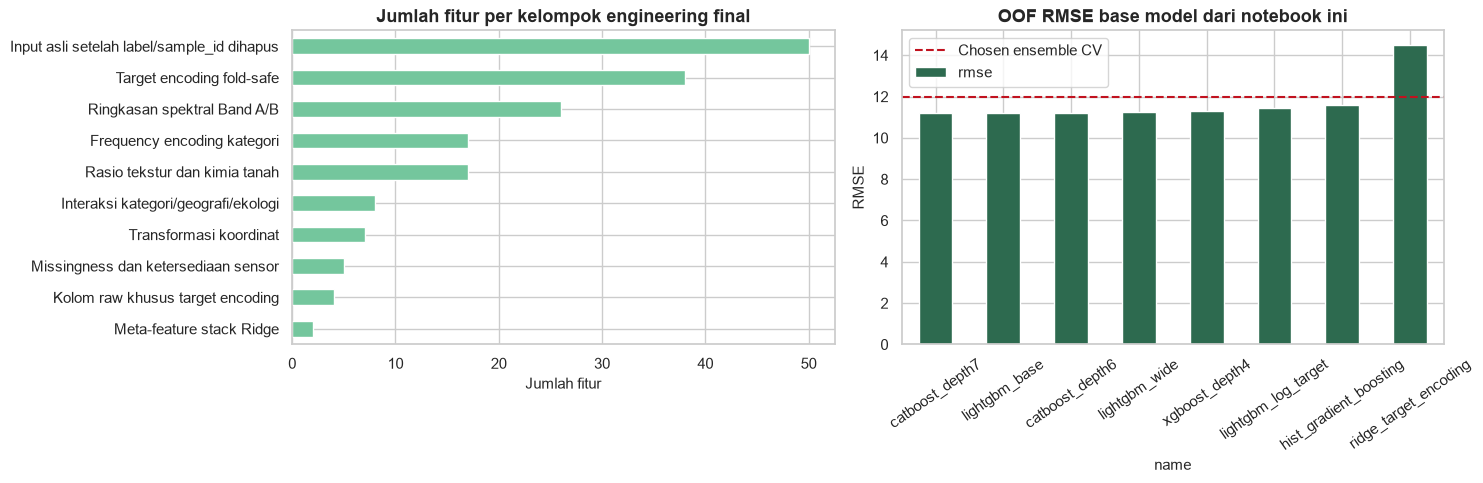

In [27]:
_, axes = plt.subplots(1, 2, figsize=(15, 5))

feature_plot = feature_inventory.set_index("kelompok_fitur")["jumlah"].sort_values()
feature_plot.plot(kind="barh", color=LIGHT_GREEN, ax=axes[0])
axes[0].set_title("Jumlah fitur per kelompok engineering final")
axes[0].set_xlabel("Jumlah fitur")
axes[0].set_ylabel("")

base_model_metrics["rmse"].sort_values().plot(kind="bar", color=GREEN, ax=axes[1])
axes[1].axhline(chosen_cv_rmse, color=RED, linestyle="--", lw=1.5, label="Chosen ensemble CV")
axes[1].set_title("OOF RMSE base model dari notebook ini")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend()

plt.tight_layout()
plt.show()


## Jawaban Soal 7

**Fitur utama yang dibuat adalah missingness, ringkasan spektral, rasio tekstur/kimia tanah, transformasi koordinat, interaksi kategori-geografi-ekologi, frequency encoding, target encoding fold-safe, dan meta-feature untuk ensemble.**

Fitur missingness membantu model membaca pola ketersediaan pengukuran, terutama karena Band B dan beberapa fitur kimia tidak selalu tersedia. Ringkasan spektral mengubah banyak principal component menjadi ukuran bentuk sinyal yang lebih mudah dipakai model, seperti mean, standar deviasi, rentang, norma, dan energi absolut.

Rasio tekstur/kimia membantu menangkap hubungan komposisi tanah, misalnya fraksi halus, rasio kation, kejenuhan basa proxy, dan interaksi acidity dengan KTK. Fitur geografi dan interaksi kategori membantu model membedakan konteks ekologis yang berbeda, misalnya kombinasi bioma dengan land cover, hierarki wilayah, serta kombinasi land cover dengan parent rock.

Target encoding dibuat secara fold-safe, sehingga statistik target untuk validasi tidak bocor dari fold validasi. Pada model final, prediksi base model digabung oleh ensemble terpilih dengan dua meta-feature: `log1p_source_count` dan `missing_total`.


# Soal 8: Model prediksi dan alasan pemilihan

> **Jelaskan model yang Anda gunakan dalam memprediksi kandungan organik tanah! Mengapa Anda memilih
> model tersebut dibanding alternatif lain, khususnya dalam konteks data yang memiliki representasi
> spektral?**


In [42]:
print_table("Base model yang masuk ke ensemble final.", base_model_metrics)
print_table("Strategi ensemble yang dievaluasi di notebook ini.", ensemble_strategy_summary)
print_table("Koefisien atau bobot ensemble final.", stack_coefficients)
print_table("Konteks pipeline final dan catatan skor publik.", final_pipeline_context)
print_table("Ringkasan prediksi test final.", pd.Series({
    "raw_prediction_min": ens_pred_clipped.min(),
    "raw_prediction_max": ens_pred_clipped.max(),
    "final_prediction_min": final_test_pred.min(),
    "final_prediction_max": final_test_pred.max(),
    "n_tail_corrected": int((ens_pred_clipped > TAIL_THRESHOLD).sum()),
}).to_frame("nilai"))


Base model yang masuk ke ensemble final.
                          rmse    mae     r2
name                                        
catboost_depth6        11.2209 6.9765 0.7660
catboost_depth7        11.2005 6.9210 0.7669
ridge_target_encoding  14.4743 9.3863 0.6107
lightgbm_base          11.2071 6.9634 0.7666
lightgbm_log_target    11.4668 6.8859 0.7557
lightgbm_wide          11.2718 6.9520 0.7639
xgboost_depth4         11.2772 7.0332 0.7637
hist_gradient_boosting 11.5738 7.2406 0.7511

Strategi ensemble yang dievaluasi di notebook ini.
                      rmse
strategy                  
linear_standard    12.0381
linear_group_aware 12.0447
stack_ridge        11.9883
stack_lgb          12.2639

Koefisien atau bobot ensemble final.
                             feature  coefficient  abs_coefficient
5           prediction_lightgbm_wide       6.0881           6.0881
1         prediction_catboost_depth7       5.2927           5.2927
4     prediction_lightgbm_log_target       4.2661       

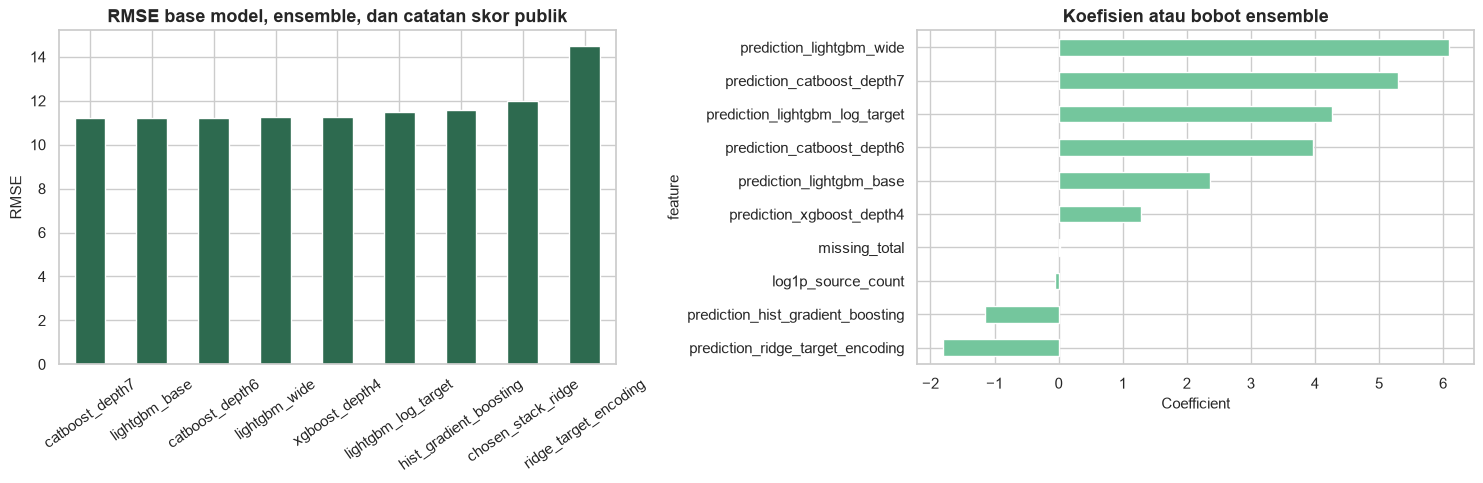

Ringkasan perbandingan model final.
                          rmse    mae     r2                                                       validation_type
final_full_stack_oof   11.0246 6.7689 0.7741              full-fit stack on OOF predictions; optimistic diagnostic
catboost_depth7        11.2005 6.9210 0.7669                              base model OOF computed in this notebook
lightgbm_base          11.2071 6.9634 0.7666                              base model OOF computed in this notebook
catboost_depth6        11.2209 6.9765 0.7660                              base model OOF computed in this notebook
lightgbm_wide          11.2718 6.9520 0.7639                              base model OOF computed in this notebook
xgboost_depth4         11.2772 7.0332 0.7637                              base model OOF computed in this notebook
lightgbm_log_target    11.4668 6.8859 0.7557                              base model OOF computed in this notebook
hist_gradient_boosting 11.5738 7.2406 0.7511

In [43]:
_, axes = plt.subplots(1, 2, figsize=(15, 5))
rmse_plot = pd.concat([
    base_model_metrics["rmse"],
    pd.Series({
        f"chosen_{chosen_strategy_name}": chosen_cv_rmse,
    })
]).sort_values()
rmse_plot.plot(kind="bar", color=GREEN, ax=axes[0])
axes[0].set_title("RMSE base model, ensemble, dan catatan skor publik")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=35)

coef_plot = stack_coefficients.set_index("feature")["coefficient"].sort_values()
coef_plot.plot(kind="barh", color=LIGHT_GREEN, ax=axes[1])
axes[1].set_title("Koefisien atau bobot ensemble")
axes[1].set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

print_table("Ringkasan perbandingan model final.", model_comparison)


## Jawaban Soal 8

**Model yang dipilih adalah stacked ensemble karena data berisi sinyal campuran: spektral, kimia tanah, tekstur, geografi, kategori, missingness, dan perbedaan sumber data.**

Ensemble ini menggabungkan CatBoost, Ridge dengan target encoding, LightGBM, XGBoost, dan HistGradientBoosting. Prediksi dari base model kemudian digabungkan memakai strategi ensemble yang dipilih dari validasi `source_id` GroupKFold, dengan meta-feature `log1p_source_count` dan `missing_total`.

Model boosting dipakai karena mampu menangkap relasi nonlinear dan interaksi fitur. Ridge target encoding memberi baseline linear yang stabil, sedangkan stack Ridge menggabungkan kekuatan masing-masing model tanpa membuat meta-model terlalu kompleks.

Koreksi ekor tinggi diterapkan pada prediksi test akhir dengan rumus `prediction - 0.316 * max(prediction - 85, 0)`. Format prediksi final divalidasi langsung dari `test.csv`, sehingga susunan kolom, urutan `sample_id`, nilai finite, dan non-negativity terjaga.


# Soal 9: Apakah RMSE tepat?

> **Menurut Anda, apakah metrik penilaian RMSE tepat untuk kasus prediksi kandungan organik tanah ini?
> Jika tidak, metrik apa yang lebih tepat? Elaborasikan jawaban Anda dengan mempertimbangkan
> karakteristik distribusi target!**

## Pendekatan dan asumsi

Membandingkan RMSE, MAE, MedianAE, RMSLE, dan kontribusi squared error per desil target. Ini diperlukan karena target right-skewed, sehingga nilai organik tinggi dapat mendominasi RMSE.


Metrik final agar RMSE tidak dibaca sendirian.
                         nilai
RMSE                   11.0246
MAE                     6.7689
MedianAE                4.1504
RMSLE                   0.2884
R2                      0.7741
Full_stack_OOF_RMSE    11.0246
Nested_GroupKFold_RMSE 11.9883

Error OOF final per desil target.
                      n  target_mean     MAE      MSE  squared_error_sum  share_total_squared_error
target_decile                                                                                      
(2.156, 12.944]    1150      10.6120  6.0801  82.5599        94,943.9316                     0.0697
(12.944, 16.18]    1109      15.0017  3.9854  41.6978        46,242.8469                     0.0339
(16.18, 19.902]    1132      18.3424  3.7590  34.8046        39,398.8061                     0.0289
(19.902, 24.27]    1465      22.5067  4.0340  37.7461        55,297.9808                     0.0406
(24.27, 27.507]     890      26.2447  5.2292  81.7911        72,794.06

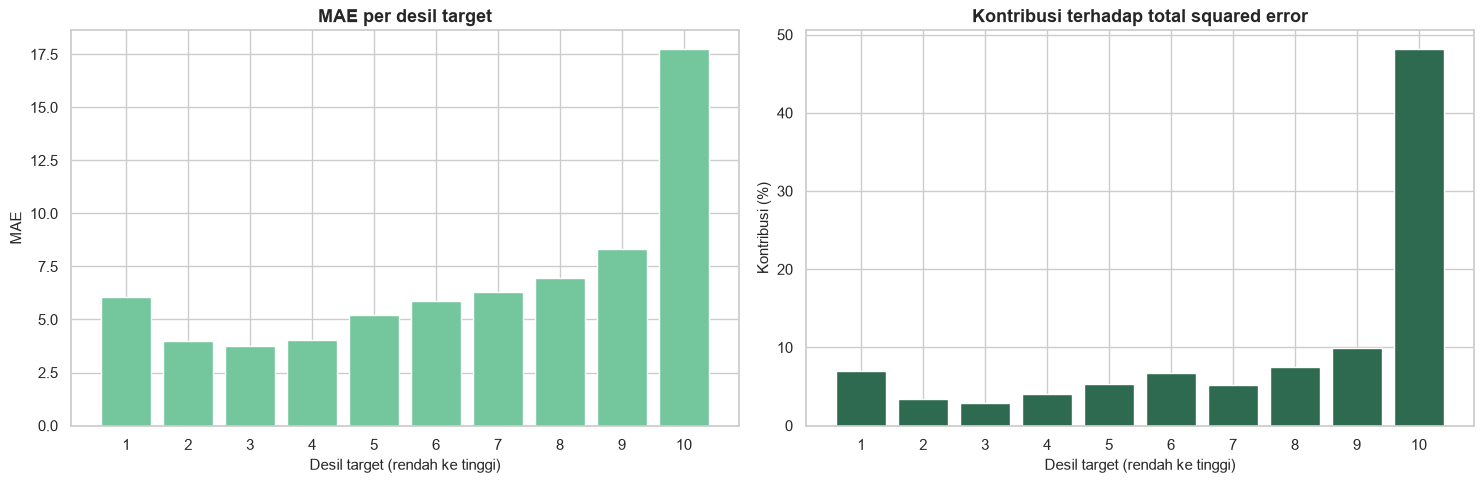

In [44]:
metric_comparison = pd.Series(regression_metrics(y_values, oof_pred), name="nilai")
metric_comparison["Full_stack_OOF_RMSE"] = metric_comparison["RMSE"]
metric_comparison["Nested_GroupKFold_RMSE"] = chosen_cv_rmse
error_analysis = pd.DataFrame({
    "actual": y_values,
    "prediction": oof_pred,
})
error_analysis["absolute_error"] = (
    error_analysis["actual"] - error_analysis["prediction"]
).abs()
error_analysis["squared_error"] = (
    error_analysis["actual"] - error_analysis["prediction"]
) ** 2
error_analysis["target_decile"] = pd.qcut(
    error_analysis["actual"], q=10, duplicates="drop"
)
decile_error = error_analysis.groupby(
    "target_decile", observed=True
).agg(
    n=("actual", "size"),
    target_mean=("actual", "mean"),
    MAE=("absolute_error", "mean"),
    MSE=("squared_error", "mean"),
    squared_error_sum=("squared_error", "sum"),
)
decile_error["share_total_squared_error"] = (
    decile_error["squared_error_sum"]
    / decile_error["squared_error_sum"].sum()
)
top_decile_share = decile_error.iloc[-1]["share_total_squared_error"] * 100

print_table("Metrik final agar RMSE tidak dibaca sendirian.", metric_comparison.to_frame())
print_table("Error OOF final per desil target.", decile_error)
print(f"Kontribusi desil target tertinggi terhadap total squared error: {top_decile_share:.1f}%")

_, axes = plt.subplots(1, 2, figsize=(15, 5))
decile_labels = [str(i + 1) for i in range(len(decile_error))]
axes[0].bar(decile_labels, decile_error["MAE"], color=LIGHT_GREEN)
axes[0].set_title("MAE per desil target")
axes[0].set_xlabel("Desil target (rendah ke tinggi)")
axes[0].set_ylabel("MAE")

axes[1].bar(
    decile_labels, decile_error["share_total_squared_error"] * 100,
    color=GREEN
)
axes[1].set_title("Kontribusi terhadap total squared error")
axes[1].set_xlabel("Desil target (rendah ke tinggi)")
axes[1].set_ylabel("Kontribusi (%)")
plt.tight_layout()
plt.show()


## Jawaban Soal 9

**RMSE tepat sebagai metrik utama kompetisi, tetapi tidak cukup sebagai satu-satunya metrik evaluasi.**

Alasannya, target memiliki ekor kanan panjang dan beberapa nilai sangat tinggi. RMSE akan memberi penalti besar pada error di sampel ekstrem, sehingga cocok jika kesalahan besar memang dianggap mahal.

Namun output desil menunjukkan bahwa sebagian besar squared error dapat terkonsentrasi pada target tinggi. Artinya model bisa terlihat buruk karena gagal pada sedikit sampel ekstrem, meskipun performa pada mayoritas sampel cukup baik.

Rekomendasinya adalah tetap memakai RMSE untuk konsistensi kompetisi, tetapi mendampinginya dengan MAE, MedianAE, RMSLE, serta audit per zona, bioma, ketersediaan Band B, dan desil target.


# Soal 10: Data eksternal

> **Jika Anda boleh mengambil data eksternal, data tentang apa yang akan Anda ambil untuk meningkatkan
> akurasi prediksi kandungan organik tanah? Jelaskan alasan pemilihannya dan bagaimana data tersebut
> dapat diintegrasikan ke dalam pipeline pemodelan Anda!**

## Pendekatan dan asumsi

Menyusun daftar sumber data eksternal yang relevan dengan proses pembentukan bahan organik tanah. Fokusnya adalah iklim, topografi, vegetasi, penggunaan lahan, dan sifat tanah, dengan catatan penting tentang risiko leakage.


In [45]:
external_data_plan = pd.DataFrame([
    {
        "sumber": "ERA5-Land",
        "variabel": "rainfall, temperature, soil moisture, evapotranspiration",
        "nilai_tambah": "menggambarkan produksi biomassa dan laju dekomposisi",
        "integrasi": "spatial join + agregasi 1/3/5 tahun sebelum sampling",
        "risiko": "resolusi lebih kasar dari titik tanah",
    },
    {
        "sumber": "Copernicus DEM / SRTM",
        "variabel": "elevation, slope, aspect, curvature, wetness index",
        "nilai_tambah": "menangkap drainase, erosi, dan akumulasi material",
        "integrasi": "extract raster dan terrain derivatives pada koordinat",
        "risiko": "koordinat hilang pada banyak sampel",
    },
    {
        "sumber": "Sentinel-2 / Landsat",
        "variabel": "NDVI/EVI, bare-soil index, moisture, burn history",
        "nilai_tambah": "proxy vegetasi, residu, gangguan, dan perubahan tutupan",
        "integrasi": "cloud masking + seasonal composites sebelum sampling",
        "risiko": "awan, tanggal sampling, dan mixed pixels",
    },
    {
        "sumber": "SoilGrids",
        "variabel": "clay, silt, sand, bulk density, SOC, pH",
        "nilai_tambah": "prior spasial sifat tanah global",
        "integrasi": "extract per depth yang sesuai 0-20 cm",
        "risiko": "target leakage bila memakai layer SOC kontemporer tanpa audit",
    },
    {
        "sumber": "MapBiomas Brasil",
        "variabel": "land-cover history, transition, fire, agriculture/pasture age",
        "nilai_tambah": "riwayat penggunaan lahan lebih informatif dari label snapshot",
        "integrasi": "annual history + transition counts sebelum sampling",
        "risiko": "ketidakselarasan tahun dan klasifikasi",
    },
])
print_table("Kandidat data eksternal, nilai tambah, cara integrasi, dan risikonya.", external_data_plan)


Kandidat data eksternal, nilai tambah, cara integrasi, dan risikonya.
                  sumber                                                       variabel                                                   nilai_tambah                                              integrasi                                                         risiko
0              ERA5-Land       rainfall, temperature, soil moisture, evapotranspiration           menggambarkan produksi biomassa dan laju dekomposisi   spatial join + agregasi 1/3/5 tahun sebelum sampling                          resolusi lebih kasar dari titik tanah
1  Copernicus DEM / SRTM             elevation, slope, aspect, curvature, wetness index              menangkap drainase, erosi, dan akumulasi material  extract raster dan terrain derivatives pada koordinat                            koordinat hilang pada banyak sampel
2   Sentinel-2 / Landsat              NDVI/EVI, bare-soil index, moisture, burn history        proxy vegetasi, residu, gang

## Jawaban Soal 10

**Data eksternal paling penting untuk ditambahkan adalah iklim historis, topografi, riwayat vegetasi/tutupan lahan, dan sifat tanah resolusi tinggi.**

Variabel tersebut mengisi mekanisme yang belum sepenuhnya terlihat dari spektrum dan kategori wilayah. Iklim membantu menjelaskan produksi biomassa dan dekomposisi, topografi menjelaskan drainase/erosi, riwayat vegetasi menjelaskan input bahan organik, dan sifat tanah resolusi tinggi membantu membaca konteks fisik-kimia tanah.

Cara integrasinya:

1. validasi kualitas koordinat dan sistem proyeksi;
2. spatial join raster ke titik sampling;
3. agregasi temporal hanya dari periode sebelum sampling;
4. rekayasa fitur tren, variasi musiman, dan perubahan tutupan lahan;
5. pencatatan sumber, resolusi, dan tanggal data;
6. evaluasi menggunakan validasi berbasis wilayah atau sumber;
7. ablation untuk memastikan setiap sumber data benar-benar meningkatkan generalisasi.

SoilGrids SOC perlu diperlakukan hati-hati karena dapat menjadi proxy target dan menimbulkan leakage. Lebih aman memulai dari clay, bulk density, pH, topografi, iklim, dan riwayat tutupan lahan. Jika layer SOC digunakan, tahun, sumber observasi, dan overlap dengan data training harus diaudit.

Sumber resmi:

- [ERA5-Land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)
- [Copernicus DEM](https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM)
- [Sentinel-2](https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html)
- [SoilGrids](https://isric.org/explore/soilgrids)
- [MapBiomas Brasil](https://brasil.mapbiomas.org/en/)

**Keterbatasan:** sebagian besar koordinat pada dataset hilang. Data raster baru bisa dimanfaatkan penuh jika koordinat lebih lengkap atau ada kunci lokasi administratif yang dapat dipetakan.
